<div style="color:white;
            display:fill;
            border-radius:10px;
            background-color:#0e2f52;
            font-size:140%;
            font-family:Verdana;
            letter-spacing:1px;
            padding: 20px;
            text-align:center;
            font-weight: bold;">
     ONLINE RETAIL CUSTOMER ANALYSIS:
</div>


<div style="text-align: center; font-size:140%; font-weight: bold; color: #20a0ff;">
     📊 EDA | 🔧 Feature Engineering | 💰 RFM Analysis | 🔍 PCA Dimensionality Reduction
</div>

    
---
    
<div style="text-align: center;">
  <b>Duygu Jones | Data Scientist </b>
    
  <br>
  Follow me:
  <a href="https://duygujones.vercel.app/">duygujones.com</a> | 
  <a href="https://www.linkedin.com/in/duygujones/">Linkedin</a> | 
  <a href="https://github.com/Duygu-Jones">GitHub</a> | 
  <a href="https://www.kaggle.com/duygujones">Kaggle</a> | 
  <a href="https://medium.com/@duygujones">Medium</a> | 
  <a href="https://public.tableau.com/app/profile/duygu.jones/vizzes">Tableau</a>
</div>    

## <font color=#20a0ff> <b>Project Description</b><font>
    
This project explores the online retail world by analyzing a complete dataset from a UK-based retailer, covering all sales between December 2010 and December 2011. The retailer sells unique gifts for different occasions, with many customers being wholesalers.
    
- The main goal is to improve marketing strategies and increase sales by finding patterns in -customer data.
- We will start with a thorough Exploratory Data Analysis (EDA), examining each column in the dataset carefully to understand customer behavior, product popularity, and sales trends.
- By using Principal Component Analysis (PCA), we will simplify the complex data into fewer dimensions, making it easier to see hidden patterns in customer behavior.
- This approach will help identify the key factors that influence customer purchases and allow for better visualization of customer data.
- The insights from our analysis will help create better marketing strategies for different types of customers, improving customer satisfaction and increasing sales.

    
### <font color=#20a0ff> <b>Problem Statement</b><font>
- As online retail grows quickly, businesses find it harder to understand their customer data, which often has many different aspects to consider. Without good data analysis methods, important patterns in customer behavior may remain hidden in large datasets. This project aims to solve this problem by first conducting detailed EDA to understand each aspect of the data, and then using PCA to simplify the complex information. By reducing the number of variables while keeping the important information, we can find useful patterns, identify what drives customer behavior, and create better marketing plans to engage customers and increase sales.   

**Note**: 
- Due to the detailed nature of this analysis, this notebook focuses solely on Exploratory Data Analysis (EDA) and Principal Component Analysis (PCA).
- As a suggested next step, K-means clustering could be implemented in a second part to segment customers based on the insights gained from PCA.
- Additionally, a recommendation system could be developed using these customer segments to suggest products based on customer preferences and behaviour patterns.
    
### <font color=#20a0ff> <b>About the Dataset</b><font>
- This dataset is derived from a UK-based online retailer and includes all transactions between December 2010 and December 2011. The retailer specializes in unique gifts for various occasions, with many customers being wholesalers. The dataset provides a detailed record of transactions, including product details, customer information, and purchase history.

*The Online Retail dataset is widely used for customer segmentation, clustering, customer relationship analysis and recommendation system development, making it a valuable resource for analyzing customer behavior in the retail sector.*

- **Dataset:** E-commerce Dataset / Online Retail Dataset  
- **Content:** Data on transactions including product details, customer information, and purchase history.  
- **Number of Rows:** 541,909  
- **Number of Columns:** 8  

| **INPUTS**         | **Description**                                                                                       |
|--------------------|-------------------------------------------------------------------------------------------------------|
| **InvoiceNo**      | Unique identifier for each transaction/invoice.                                                       |
| **StockCode**      | Unique identifier for each product (product code).                                                    |
| **Description**    | Description of the product.                                                                           |
| **Quantity**       | The quantity of each product per transaction.                                                         |
| **InvoiceDate**    | Date and time when the transaction occurred.                                                          |
| **UnitPrice**      | Price of the product per unit.                                                                        |
| **CustomerID**     | Unique identifier for each customer.                                                                  |
| **Country**        | The country where the customer resides.                                                               |


**Reference:**
 UCI Machine Learning Repository. (2015). Online Retail Dataset. https://archive.ics.uci.edu/dataset/352/online+retail

<a id="contents_tabel"></a>    

<h3 align="left"><font color=#20a0ff>Table of Contents:</font></h3>

- <a href='#setup'>Setup and Initialization</a>
    - <a href='#import-libraries'>Import the Libraries</a>
    - <a href='#load-dataset'>Load the Dataset</a>
- <a href='#eda'>Exploratory Data Analysis (EDA)</a>
    - <a href='#descriptive-statistics'>Descriptive Statistics</a>
    - <a href='#data-cleaning'>Data Cleaning and Transformation</a>
    - <a href='#duplicated-values'>Handling Duplicated Values</a>
    - <a href='#missing-values'>Handling Missing Values</a>
- <a href='#feature-engineering'>Feature Engineering for Customer Profiling</a>
    - <a href='#cancelled'>Detecting Cancelled Transactions</a>
    - <a href='#total-price'>Creating Total_Price Column</a>
    - <a href='#purchase-metrics'>Features for Purchase Metrics</a>
    - <a href='#shopping-patterns'>Features for Customer Shopping Patterns</a>
- <a href='#outlier-analysis'>Outlier Analysis</a>
- <a href='#correlation'>Correlation Matrix</a>
- <a href='#rfm'>RFM Analysis</a>
    - <a href='#rfm'>Recency (R)</a>
    - <a href='#rfm'>Frequency (F)</a>
    - <a href='#rfm'>Monetary (M)</a>
- <a href='#data-preprocessing'>Data Preprocessing</a>
- <a href='#scaling'>Scaling the Data</a>
- <a href='#pca'>PCA - Principal Component Analysis</a>
- <a href='#conclusion'>Conclusion</a>
   

<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;"> Setup and Initialization</p> 

## Import the Libraries

In [87]:
# Data processing and analysis libraries
import numpy as np
import pandas as pd
from collections import Counter

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
import plotly.graph_objects as go

# Statistical analysis and modeling libraries
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Clustering visualization tools
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Matplotlib settings
%matplotlib inline
plt.rcParams["figure.figsize"] = (10,6)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Initialize Plotly for use in the notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

## Load the Dataset

In [88]:
df0 = pd.read_csv('/kaggle/input/ecommerce-data/data.csv', encoding="ISO-8859-1", dtype={'CustomerID': str})
df = df0.copy()

In [89]:
df.shape

(541909, 8)

In [90]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [91]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680,France


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [93]:
# Numerical and Categorial Dataframes to use later
cat_df = df.select_dtypes(include='object')
num_df = df.select_dtypes(include='number')

print('Categoricals:', list(cat_df))
print('----------------------------------------------------------------------------------')
print('Numericals:',list(num_df))

Categoricals: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'Country']
----------------------------------------------------------------------------------
Numericals: ['Quantity', 'UnitPrice']


<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;"> Exploratory Data Analysis (EDA)</p> 

## Descriptive Statistics

In [94]:
# Summary of the Dataset

def summary(df,pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    Min = df.min(numeric_only=True)
    Max = df.max(numeric_only=True)
    
    # Calculate the percentage of null values
    NullPercent = (Nulls / obs) * 100
    
    # Calculate the number of duplicate rows
    duplicate_count = df.duplicated().sum()
    
    #Number of missing Values
    missing_count = df.isnull().sum().sum()
    
    # Create a new column to store unique values for columns with 10 or fewer unique values, otherwise '-'
    UniqueValues = df.apply(lambda x: list(x.unique()) if x.nunique() <= 10 else '-')

    # Display df.shape and duplicate count at the beginning
    print(f'-> Data shape (rows, columns): {df.shape}')
    print(f'-> Number of duplicate rows: {duplicate_count}')
    print(f'-> Number of missing values: {missing_count}')
    
    if pred is None:
        # Adjusted order with 'Uniques' at a more prominent position
        summary_df = pd.DataFrame({
            'Dtype': Types, 
            'Counts': Counts, 
            'Nulls': Nulls, 
            'NullPercent': NullPercent, 
            'Min': Min, 
            'Max': Max, 
            'Uniques': Uniques,
            'UniqueValues': UniqueValues
        })

    print('___________________________\nData Types:')
    print(summary_df['Dtype'].value_counts())
    print('___________________________')
    return summary_df

summary(df)

-> Data shape (rows, columns): (541909, 8)
-> Number of duplicate rows: 5268
-> Number of missing values: 136534
___________________________
Data Types:
Dtype
object     6
int64      1
float64    1
Name: count, dtype: int64
___________________________


,Dtype,Counts,Nulls,NullPercent,Min,Max,Uniques,UniqueValues
Country,object,541909,0,0.000000,NaN,NaN,38,-
CustomerID,object,406829,135080,24.926694,NaN,NaN,4373,-
Description,object,540455,1454,0.268311,NaN,NaN,4224,-
InvoiceDate,object,541909,0,0.000000,NaN,NaN,23260,-
InvoiceNo,object,541909,0,0.000000,NaN,NaN,25900,-
Quantity,int64,541909,0,0.000000,-80995.00,80995.0,722,-
StockCode,object,541909,0,0.000000,NaN,NaN,4070,-
UnitPrice,float64,541909,0,0.000000,-11062.06,38970.0,1630,-


In [95]:
# Summary statistics of Numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0


**Numerical Features:**
- **Outliers Detected**: There are clear outliers in both `Quantity` and `UnitPrice` that need to be addressed.
- **Negative Values**: Negative values in `Quantity` and `UnitPrice` are present, likely due to **cancelled transactions**.
- **Missing Values**: Missing data is observed in `CustomerID` and `Description`, which will require handling.
- **Derived Feature**: `Quantity` and `UnitPrice` should be multiplied to create a new feature, **Total Price**.

In [96]:
# Summary statistics of Object features

df.describe(include= 'object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
CustomerID,406829,4372,17841,7983
Country,541909,38,United Kingdom,495478


**Categorcal Features:**
- **InvoiceNo**: There are 54,1909 unique invoices, with the most frequent invoice number being `573585`, appearing 1,114 times. This suggests that certain invoices are repeated frequently, possibly indicating batch orders or recurring transactions.
- **StockCode**: The dataset contains 4,070 unique product codes, with `85123A` being the most common, appearing 2,313 times. This indicates that certain products are more frequently sold.
- **Description**: There are 4,223 unique product descriptions, with `WHITE HANGING HEART T-LIGHT HOLDER` being the most frequent, appearing 2,369 times. This suggests this product is a best-seller.
- **InvoiceDate**: There are 23,260 unique invoice dates, with the most frequent being `10/31/2011 14:41`, appearing 1,114 times. This could indicate a high volume of transactions at that specific time.
- **Country**: The dataset includes transactions from 38 countries, with the majority (495,478) occurring in the United Kingdom, indicating that this is the primary market for the retailer.

<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;">Data Cleaning and Transformation</p> 

- In this part of the project, a thorough data cleaning and transformation process is carried out to optimize the dataset. 
- This includes addressing missing values, removing duplicate entries, correcting inconsistencies in product codes and descriptions, and making other essential adjustments. 
- These steps are crucial to prepare the data for accurate analysis and effective modeling.

In [97]:
# =============== User-Defined-Function ======================================================

# Fonction for count and percentage of values for each column
def get_value_count(df, column_name):
    vc = df[column_name].value_counts()
    vc_norm = df[column_name].value_counts(normalize=True)
    
    vc = vc.rename_axis(column_name).reset_index(name='counts')
    vc_norm = vc_norm.rename_axis(column_name).reset_index(name='percent')
    vc_norm['percent'] = (vc_norm['percent'] * 100).map('{:.2f}%'.format)
    
    df_result = pd.concat([vc[column_name], vc['counts'], vc_norm['percent']], axis=1)
    
    return df_result

# ========== User-Defined-Function for Missing Values =========================================
def missing_values(df):

    missing_count = df.isnull().sum()
    value_count = df.isnull().count()
    missing_percentage = round(missing_count / value_count * 100, 2)
    missing_df = pd.DataFrame({"count": missing_count, "percentage": missing_percentage})
    return missing_df
#==============================================================================================

## Handling Duplicated Values

- Duplicate rows in this dataset, including identical transaction times, likely represent data entry errors rather than true repeated transactions. 
- Keeping these duplicates could introduce noise and inaccuracies into the clustering and recommendation processes. 
- Therefore, removing these exact duplicates will ensure a cleaner dataset, leading to more accurate customer segmentation and a more reliable recommendation system.

In [98]:
# Checks duplicates and drops them

def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep='first').sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep='first', inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are 5268 duplicated observations in the dataset.
5268 duplicates were dropped!
No more duplicate rows!


## Handling Missing Values


- **`CustomerID`**: (135,037 missing values, 24.93%)
    - The 'CustomerID' column represents unique identifiers for each customer.
    - Given the high percentage of missing data in this critical column, imputing values could introduce bias. 
    - Therefore, dropping rows with missing 'CustomerID's ensures the accuracy and reliability of customer clustering.


- **`Description`**: (1,454 missing values, 0.27%)
    - The 'Description' column provides details about the products sold. 
    - Although the missing percentage is low, inconsistencies in 'StockCode' and 'Description' data suggest quality issues. 
    - Removing rows with missing 'Description's helps maintain data integrity and avoids potential errors in analysis. 
    - Additionally, all 1,454 rows with missing 'Description' also have missing 'CustomerID', further justifying their removal to avoid incomplete and unreliable data.

By removing these rows, we ensure a cleaner dataset, essential for accurate clustering and effective recommendations.

In [99]:
missing_values(df)

,count,percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135037,25.16
Country,0,0.00


In [100]:
# Check how many rows with a missing Description also have a missing CustomerID

df[df.Description.isnull()].CustomerID.isnull().value_counts()

CustomerID
True    1454
Name: count, dtype: int64

In [101]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns

common_missings = df[df['CustomerID'].isnull() | df['Description'].isnull()]

print(common_missings.shape)
common_missings.head()

(135037, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [102]:
# Find 'StockCodes' with multiple unique 'Descriptions'
df.groupby(['StockCode', 'Description']).size().reset_index(name='Count').head(10)

,StockCode,Description,Count
0,10002,INFLATABLE POLITICAL GLOBE,71
1,10080,GROOVY CACTUS INFLATABLE,22
2,10080,check,1
3,10120,DOGGY RUBBER,29
4,10123C,HEARTS WRAPPING TAPE,3
5,10124A,SPOTS ON RED BOOKCOVER TAPE,5
6,10124G,ARMY CAMO BOOKCOVER TAPE,4
7,10125,MINI FUNKY DESIGN TAPES,93
8,10133,COLOURING PENCILS BROWN TUBE,197
9,10133,damaged,1


In [103]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['CustomerID', 'Description'])

In [104]:
# Verifying the removal of missing values
df.isnull().sum().sum()

0

In [105]:
# Check all rows with either NaN or empty string("") values or string "nan" values
df[df.isna().any(axis=1) | (df == "").any(axis=1) | (df == "nan").any(axis=1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [106]:
missing_values(df)

,count,percentage
InvoiceNo,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,0,0.0
Country,0,0.0


## "StockCode" Column

`StockCode`: Unique identifier for each product (product code).

- **Product Variety**: With 3,684 unique stock codes, the dataset showcases a diverse range of products, which could help identify distinct customer segments.
- **Popular Items**: Examining the top 10 stock codes reveals the most frequently purchased products, offering insights into customer preferences.
- **Unusual Stock Code**: Some stock codes, like 'POST', deviate from the typical 5-6 character length, likely representing non-product transactions. These should be investigated to ensure data accuracy for clustering and recommendations.

In [107]:
print('Number of Unique StockCodes: ',df['StockCode'].nunique())

# Call the function to count unique values and percentages
get_value_count(df, 'StockCode').head(10)

Number of Unique StockCodes:  3684


,StockCode,counts,percent
0,85123A,2065,0.51%
1,22423,1894,0.47%
2,85099B,1659,0.41%
3,47566,1409,0.35%
4,84879,1405,0.35%
5,20725,1346,0.34%
6,22720,1224,0.30%
7,POST,1196,0.30%
8,22197,1110,0.28%
9,23203,1108,0.28%


In [108]:
# Finding the number of numeric characters in each unique stock code
pd.Series(df['StockCode'].unique()).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

5    3676
0       7
1       1
Name: count, dtype: int64

Number of numeric characters in each unique stock code:
- 5: majority of the unique stock codes (3676 out of 3684) contain exactly 5 numeric characters
- 0: 7 stock codes contain no numeric characters 
- 1: 1 stock code contains only 1 numeric character

In [109]:
# Finding the stock codes with 0 and 1 numeric characters
unusual_stockCodes = [code for code in df['StockCode'].unique() if sum(c.isdigit() for c in str(code)) in (0, 1)]

print('unusual_stockCodes: ', unusual_stockCodes)
print(f"Total count of unusual StockCodes: {df['StockCode'].isin(unusual_stockCodes).sum()}")
print(f"Percentage of Unusual StockCodes: {df['StockCode'].isin(unusual_stockCodes).sum() / len(df) * 100:.2f}%")

unusual_stockCodes:  ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']
Total count of unusual StockCodes: 1915
Percentage of Unusual StockCodes: 0.48%


- Only 0.48% of the records have unusual stock codes, representing just 8 out of 3,684 unique codes.    
These codes likely correspond to non-product transactions like "BANK CHARGES" or "POST," and including them in the analysis could introduce noise and skew the results in clustering and recommendation systems.
- Since the project aims to cluster customers based on their product purchases and develop a recommendation system, it's important to remove records with unusual stock codes.   
These codes often represent non-product transactions, such as service charges or fees, which don't reflect actual purchasing behavior.   
By excluding them, the analysis stays focused on genuine product transactions, leading to more accurate customer clusters and better recommendations.

In [110]:
print('df Shape Before removal: ', df.shape)

# Removing rows with Unusual stock codes from the dataset
df = df[~df['StockCode'].isin(unusual_stockCodes)]

print('df Shape After removal: ', df.shape)

df Shape Before removal:  (401604, 8)
df Shape After removal:  (399689, 8)


## "Description" Column

- The most frequent descriptions are primarily household items, including kitchenware, lunch bags, and decorative items.
- Notably, all descriptions are in uppercase, suggesting a standardized format for product entries. However, given the inconsistencies and anomalies observed in the dataset, it would be wise to verify if any descriptions are entered in lowercase or a mix of upper and lower case.

In [111]:
get_value_count(df, 'Description').head(20)

,Description,counts,percent
0,WHITE HANGING HEART T-LIGHT HOLDER,2058,0.51%
1,REGENCY CAKESTAND 3 TIER,1894,0.47%
2,JUMBO BAG RED RETROSPOT,1659,0.42%
3,PARTY BUNTING,1409,0.35%
4,ASSORTED COLOUR BIRD ORNAMENT,1405,0.35%
5,LUNCH BAG RED RETROSPOT,1345,0.34%
6,SET OF 3 CAKE TINS PANTRY DESIGN,1224,0.31%
7,LUNCH BAG BLACK SKULL.,1099,0.27%
8,PACK OF 72 RETROSPOT CAKE CASES,1062,0.27%
9,SPOTTY BUNTING,1026,0.26%


In [112]:
# Find unique descriptions containing lowercase characters
descriptions_lowercase = [desc for desc in df['Description'].unique() if any(char.islower() for char in desc)]
descriptions_lowercase

['BAG 500g SWIRLY MARBLES',
 'POLYESTER FILLER PAD 45x45cm',
 'POLYESTER FILLER PAD 45x30cm',
 'POLYESTER FILLER PAD 40x40cm',
 'FRENCH BLUE METAL DOOR SIGN No',
 'BAG 250g SWIRLY MARBLES',
 'BAG 125g SWIRLY MARBLES',
 '3 TRADITIONAl BISCUIT CUTTERS  SET',
 'NUMBER TILE COTTAGE GARDEN No',
 'FOLK ART GREETING CARD,pack/12',
 'ESSENTIAL BALM 3.5g TIN IN ENVELOPE',
 'POLYESTER FILLER PAD 65CMx65CM',
 'NUMBER TILE VINTAGE FONT No ',
 'POLYESTER FILLER PAD 30CMx30CM',
 'POLYESTER FILLER PAD 60x40cm',
 'FLOWERS HANDBAG blue and orange',
 'Next Day Carriage',
 'THE KING GIFT BAG 25x24x12cm',
 'High Resolution Image']

- After reviewing the descriptions containing lowercase characters, it is clear that some entries, like "Next Day Carriage" and "High Resolution Image," are not actual product descriptions.  
These entries appear to represent service details or other types of information unrelated to the products themselves.

In [113]:
# Unusual descriptions containing lowercase characters
unusual_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Number of unusual_descriptions
print('Number of unusual_descriptions: ', df[df['Description'].isin(unusual_descriptions)].shape[0])
print('Percentage of unusual_descriptions: ', df[df['Description'].isin(unusual_descriptions)].shape[0] / len(df) * 100)

Number of unusual_descriptions:  83
Percentage of unusual_descriptions:  0.02076614567826485


In [114]:
# Remove rows with unusual_descriptions information in the column
df = df[~df['Description'].isin(unusual_descriptions)]

df.shape

(399606, 8)

## "InvoiceNo" and "InvoiceDate" Columns
`InvoiceNo`: Unique identifier for each transaction/order.   
`InvoiceDate`:	Date and time when the transaction/order occurred.

In [115]:
# Most Frequent InvoiceDate Times
get_value_count(df, 'InvoiceDate').head(10)

,InvoiceDate,counts,percent
0,11/14/2011 15:27,541,0.14%
1,11/28/2011 15:54,532,0.13%
2,12/5/2011 17:17,528,0.13%
3,11/23/2011 13:39,442,0.11%
4,10/31/2011 14:09,434,0.11%
5,9/21/2011 14:40,420,0.11%
6,11/10/2011 12:37,376,0.09%
7,10/17/2011 13:31,363,0.09%
8,10/10/2011 17:12,352,0.09%
9,10/24/2011 17:07,351,0.09%


In [116]:
print("Datafile starts with timepoint {}".format(df.InvoiceDate.min()))
print("Datafile ends with timepoint {}".format(df.InvoiceDate.max()))

Datafile starts with timepoint 1/10/2011 10:32
Datafile ends with timepoint 9/9/2011 9:52


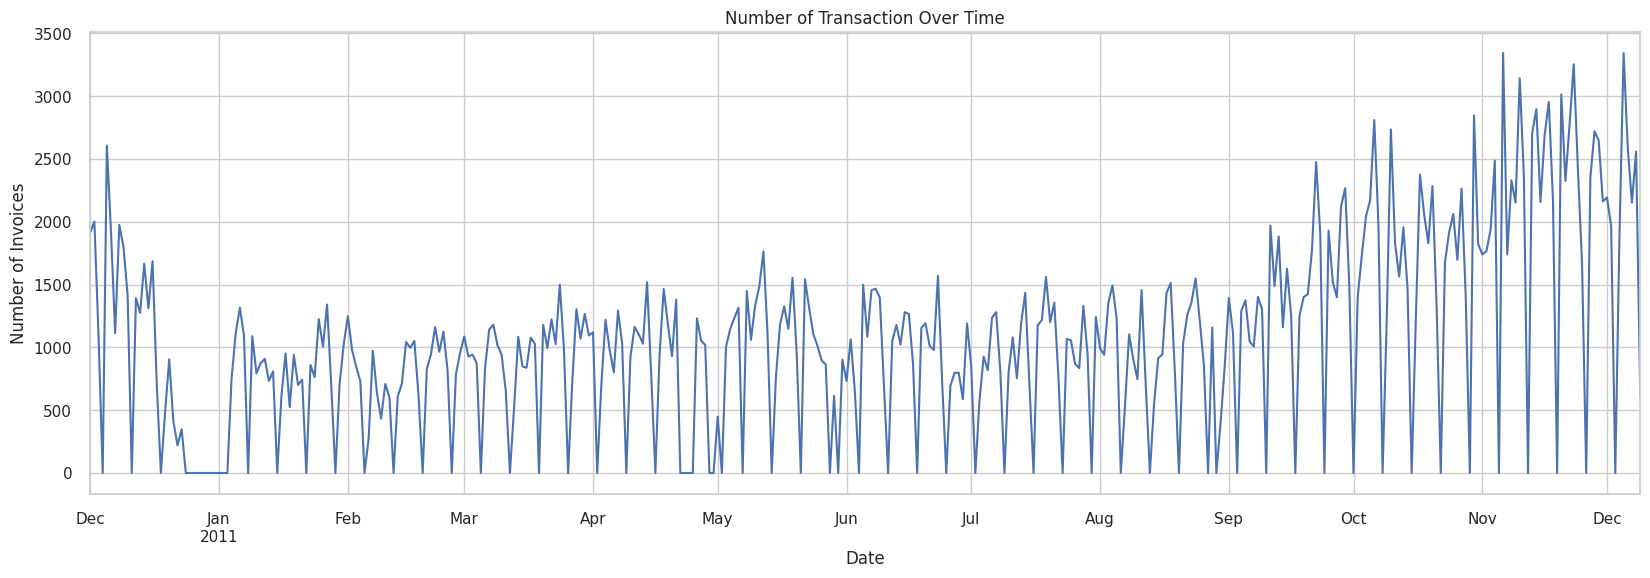

In [117]:
# COnvert the InvoiceDate columnt to Datetime 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  

#plot
df.set_index('InvoiceDate')['InvoiceNo'].resample('D').count().plot(figsize=(20, 6))
plt.xlabel('Date')
plt.ylabel('Number of Invoices')
plt.title('Number of Transaction Over Time')
plt.show()


## "CustomerID" Column

In [118]:
print('Number of Unique CustomerID: ',df['CustomerID'].nunique())

Number of Unique CustomerID:  4363


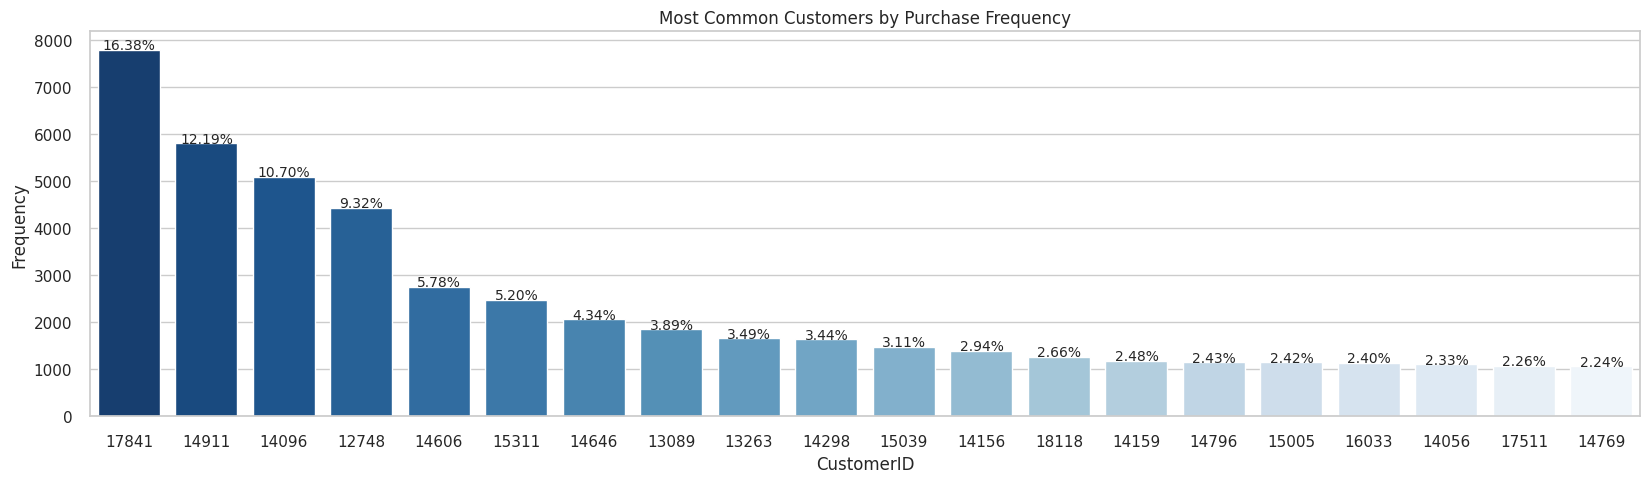

In [119]:
# Customer transaction frequency
customer_frequency = df['CustomerID'].value_counts().nlargest(20)

plt.figure(figsize=(20, 5))
ax = sns.barplot(x=customer_frequency.index.astype(str), y=customer_frequency.values, palette='Blues_r')

# Add only percentage labels on the bars
for i, v in enumerate(customer_frequency.values):
    ax.text(i, v + 10, f'{v / customer_frequency.sum() * 100:.2f}%', ha='center', fontsize=10)
    
plt.xlabel('CustomerID')
plt.ylabel('Frequency')
plt.title('Most Common Customers by Purchase Frequency')
#plt.xticks(rotation=45)
plt.show()

## "Country" Column

`Country`: This feature indicates the customer’s location, helping to identify region-specific buying patterns and preferences. Understanding these differences is crucial for tailoring marketing strategies, inventory planning, and optimizing logistics, especially for an online retailer where shipping is a key factor.

In [120]:
print('Number of Unique Countries: ',df['Country'].nunique())

Number of Unique Countries:  37


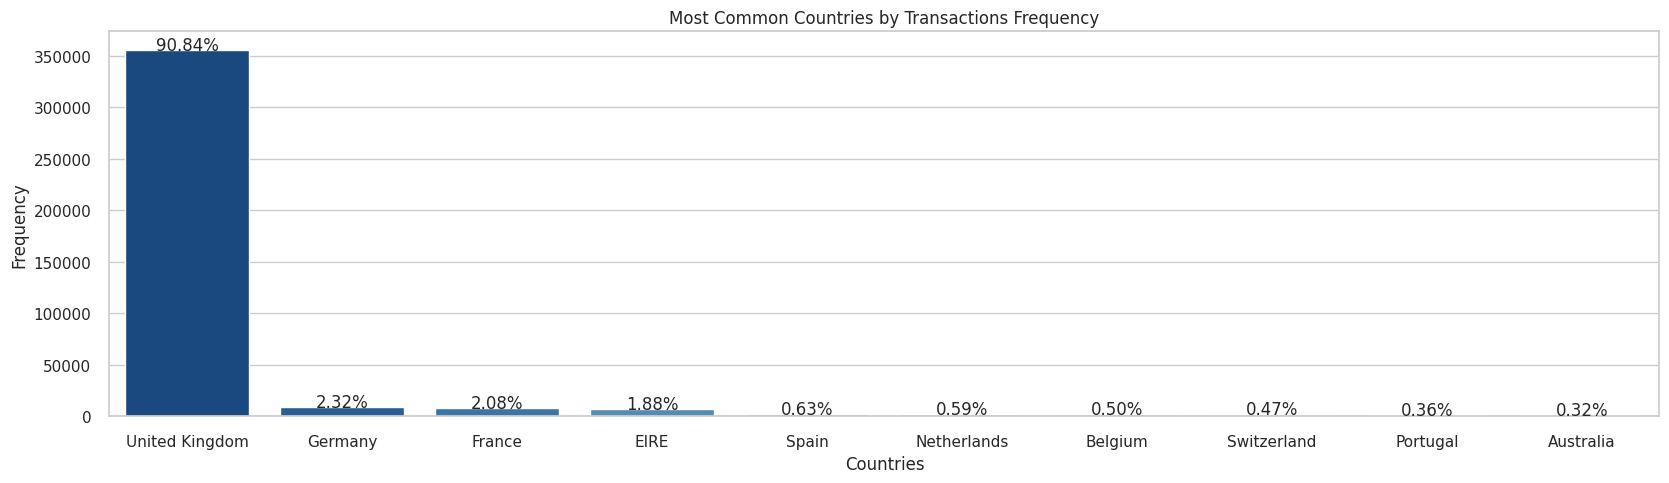

In [121]:
# Country transaction frequency
country_frequency = df['Country'].value_counts().nlargest(10)

plt.figure(figsize=(20, 5))
ax=sns.barplot(x=country_frequency.index.astype(str), y=country_frequency.values, palette='Blues_r')

# Add only percentage labels on the bars
for i, v in enumerate(country_frequency.values):
    ax.text(i, v, f'{v / country_frequency.sum() * 100:.2f}%', ha='center', fontsize=12)
   
plt.xlabel('Countries')
plt.ylabel('Frequency')
plt.title('Most Common Countries by Transactions Frequency')
#plt.xticks(rotation=45)
plt.show()

- Significant __90%__ of transactions originate from the __United Kingdom__, it may be beneficial to create a binary feature indicating whether a transaction is from the UK or not.    
This approach can simplify the clustering process while preserving essential geographical information, particularly when using algorithms like K-means that are sensitive to the number of features.

In [122]:
# Create a binary feature indicating whether the transaction is from the UK or not
df['UK'] = df['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)


df.UK.value_counts()

UK
1    356028
0     43578
Name: count, dtype: int64

## "Quantity" Column

In [123]:
df.Quantity.describe()

count    399606.000000
mean         12.231718
std         250.862855
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [124]:
# Most Frequent Quantities in Transactions
get_value_count(df, 'Quantity').head(10) 

,Quantity,counts,percent
0,1,68873,17.24%
1,12,59813,14.97%
2,2,57098,14.29%
3,6,37423,9.36%
4,4,31980,8.00%
5,3,26607,6.66%
6,24,23692,5.93%
7,10,21156,5.29%
8,8,11565,2.89%
9,5,8038,2.01%


Text(0.5, 1.0, 'Log-Quantity distribution')

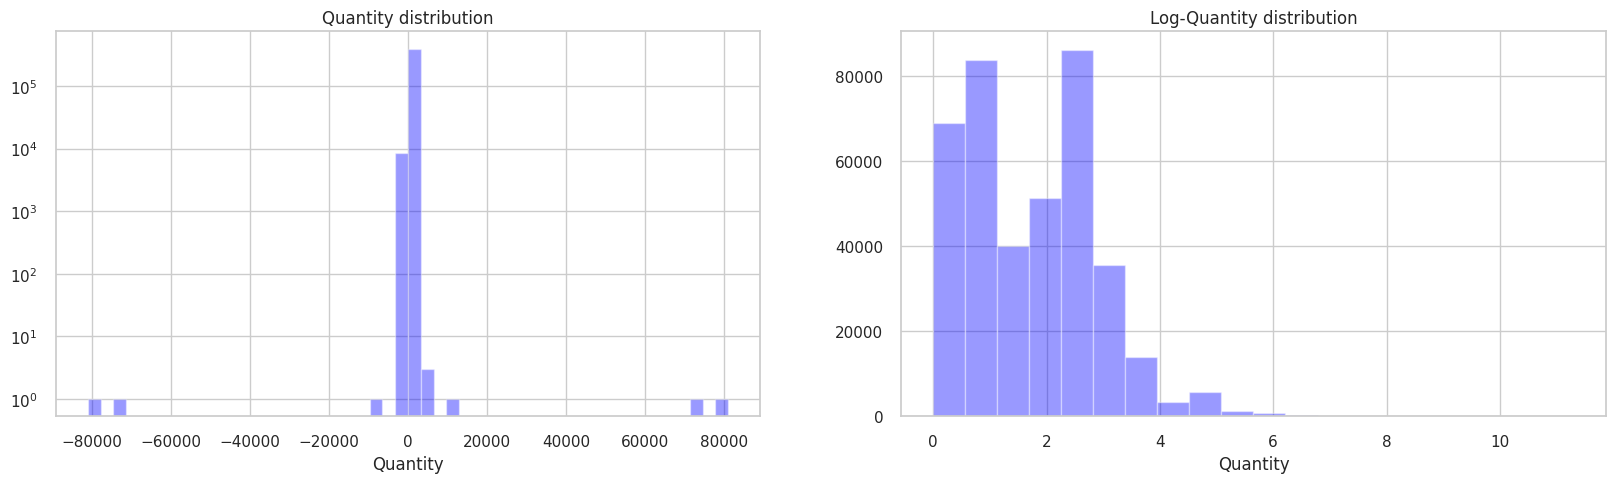

In [125]:
fig, ax = plt.subplots(1,2,figsize=(20,5))
sns.distplot(df.Quantity, ax=ax[0], kde=False, color="blue");
sns.distplot(np.log(df.Quantity), ax=ax[1], bins=20, kde=False, color="blue");
ax[0].set_title("Quantity distribution")
ax[0].set_yscale("log")
ax[1].set_title("Log-Quantity distribution")

## "UnitPrice" Column

- There are 33 transactions with a unit price of zero, which are relatively few in number.   
To avoid introducing noise in the data analysis, it's advisable to remove these transactions from the dataset.    
This will help maintain a cleaner and more consistent dataset, which is crucial for building an accurate and reliable clustering model and recommendation system.

In [126]:
get_value_count(df, 'UnitPrice').head(10)

,UnitPrice,counts,percent
0,1.25,45789,11.46%
1,1.65,36945,9.25%
2,2.95,26790,6.70%
3,0.85,26065,6.52%
4,0.42,21762,5.45%
5,4.95,18438,4.61%
6,3.75,17845,4.47%
7,2.10,17165,4.30%
8,2.08,15765,3.95%
9,1.45,12750,3.19%


In [127]:
df.UnitPrice.describe() # min 0 Unit Price!

count    399606.000000
mean          2.904957
std           4.448796
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: UnitPrice, dtype: float64

In [128]:
df[df['UnitPrice']==0].shape

(33, 9)

In [129]:
# Removing records with a unit price of zero to avoid potential data entry errors
df = df[df['UnitPrice'] > 0]

<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;"> Feature Engineering for Customer Profiling</p> 

## Detecting "Cancelled" Transactions 

<div style="border-radius:10px; padding: 15px; background-color: #295482; font-size:100%; text-align:left">
    
To gain a clearer insight into customer behavior, it's important to consider cancelled transactions.        
Cancelled transactions were identified  with `InvoiceNo` starts with "C" and Negative `Quantity` columns to analyze and uncover common patterns or characteristics within these cancelled transactions.
    
    
`Transaction_Status`:
- All quantities in the cancelled transactions are negative, indicating that these are indeed orders that were cancelled.
- The negative quantities and wide range in both Quantity and UnitPrice suggest diverse patterns of cancellations, involving both small and large transactions across a wide price range.

To effectively cluster customers and build a reliable recommendation system, it is crucial to understand and incorporate cancellation patterns.   
By retaining and marking cancelled transactions, the clustering process can capture important customer behaviors, and the recommendation system can avoid suggesting products likely to be cancelled, enhancing both accuracy and customer satisfaction.

In [130]:
df.Quantity.describe()

count    399573.000000
mean         12.197999
std         250.088282
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [131]:
# Detect cancelled transactions 

cancelled_transactions = df[(df['Quantity'] < 0) & (df['InvoiceNo'].str.contains('C', na=False))]
cancelled_transactions

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,UK
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,1
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,1
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
540448,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397,United Kingdom,1
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,1
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,1
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,1


In [132]:
# Creating the column "Transaction_Status"

# If InvoiceNo starts with "C", label the transaction as "Cancelled"; otherwise, label it as "Completed"
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')


df[df['Transaction_Status'] == 'Cancelled']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,UK,Transaction_Status
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,1,Cancelled
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,1,Cancelled
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1,Cancelled
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1,Cancelled
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,1,Cancelled
...,...,...,...,...,...,...,...,...,...,...
540448,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397,United Kingdom,1,Cancelled
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,1,Cancelled
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,1,Cancelled
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,1,Cancelled


In [133]:
# Select rows labeled as "Cancelled" and analyze their statistical characteristics
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']

# Percentage of cancelled transactions in the Dataset
print(f"\n-> The percentage of cancelled transactions in the dataset is: {len(cancelled_transactions) / len(df) * 100:.2f}%\n")

# Overall Statistics
cancelled_transactions.describe()


-> The percentage of cancelled transactions in the dataset is: 2.13%



,Quantity,InvoiceDate,UnitPrice,UK
count,8505.000000,8505,8505.000000,8505.000000
mean,-31.476778,2011-06-27 00:55:16.493827072,4.438907,0.848560
min,-80995.000000,2010-12-01 09:49:00,0.030000,0.000000
25%,-6.000000,2011-03-21 16:27:00,1.450000,1.000000
50%,-2.000000,2011-07-11 13:07:00,2.550000,1.000000
75%,-1.000000,2011-10-06 20:38:00,4.950000,1.000000
max,-1.000000,2011-12-09 11:58:00,295.000000,1.000000
std,1197.121933,NaN,9.198968,0.358499


## Creating "Total_Price" Column

<div style="border-radius:10px; padding: 15px; background-color: #295482; font-size:100%; text-align:left">
    
`Total_Price` column created by multiplying `Quantity` by `UnitPrice` to capture the total amount spent in each transaction.    
This column is essential for understanding customer spending behavior, which is critical for customer segmentation and identifying high-value customers.

In [134]:
df["Total_Price"] = df["Quantity"] * df["UnitPrice"]

In [135]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,UK,Transaction_Status,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,1,Completed,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,1,Completed,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,1,Completed,22.00


## RFM Analysis:


RFM stands for **Recency**, **Frequency**, and **Monetary** value, key metrics that help analyze customer behavior. 

1. **Recency (R):** How recently a customer made a purchase; more recent purchases suggest higher engagement and responsiveness to promotions.
2. **Frequency (F):** How often a customer buys; higher frequency indicates greater loyalty and satisfaction. 
3. **Monetary (M):** The total amount a customer spends; higher spending differentiates valuable customers from those with lower spending.

These metrics provide insights into customer preferences and behavior, essential for tailoring marketing strategies and building effective recommendation systems.

---

### New DataFrame: `customer_df`   
This new DataFrame contains the Recency, Frequency, and Monetary values for each customer,and will eventually contain all the customer-based features we plan to create.

---

In [136]:
# Create an empty  `customer_df` DataFrame grouped by `CustomerID`  representing the customer profiles 
# (which will eventually contain all the customer-based features )

# Reference date: the most recent date in the dataset
reference_date = df['InvoiceDate'].max()

customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),  # Recency: Days since last purchase
    Frequency=('InvoiceNo', 'nunique'),  # Frequency: Number of unique transactions
    Monetary=('Total_Price', 'sum')      # Monetary: Sum of total purchase amount
).reset_index()

customer_df = customer_df[customer_df['Monetary'] > 0]

# Display the first few rows of customer_df
print('customer_df shape: ', customer_df.shape)
customer_df.head()

customer_df shape:  (4324, 4)


,CustomerID,Recency,Frequency,Monetary
1,12347,1,7,4310.00
2,12348,74,4,1437.24
3,12349,18,1,1457.55
4,12350,309,1,294.40
5,12352,35,8,1265.41


### 1. Recency (R)

In this step, the focus is on understanding how recently a customer made a purchase, which is key for customer segmentation. The feature to be defined is:

- **Days Since Last Purchase:** This measures the number of days since the customer’s last purchase. A lower value indicates recent activity and higher engagement, while a higher value suggests decreased engagement. By analyzing recency, businesses can adjust their marketing strategies to re-engage inactive customers, boosting retention and loyalty.

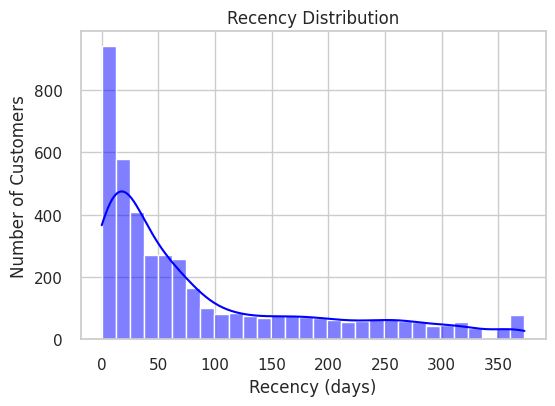

In [137]:
# Recency plot
plt.figure(figsize=(6,4))
sns.histplot(x=customer_df['Recency'], bins=30, kde=True, color='blue')
plt.title('Recency Distribution')  
plt.xlabel('Recency (days)')       
plt.ylabel('Number of Customers')  
plt.show()

### 2. Frequency (F)

`Frequency` column is been created to count the number of unique transactions each customer has made.    
This is essential for customer segmentation because it helps us understand how often customers engage with the retailer, which is a key indicator of customer loyalty and behavior.

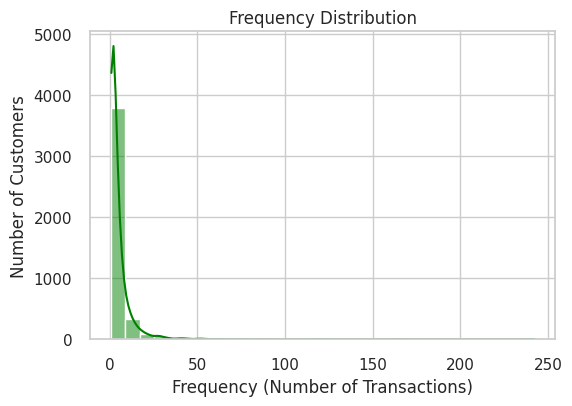

In [138]:
# Frequency
plt.figure(figsize=(6,4))
sns.histplot(x=customer_df['Frequency'], bins=30, kde=True, color='green')  # Changed x and color for Frequency
plt.title('Frequency Distribution')  
plt.xlabel('Frequency (Number of Transactions)')       
plt.ylabel('Number of Customers')  
plt.show()

### 3. Monetary (M)

`Monetary (M)` value in RFM analysis represents the total amount of money spent by a customer.    
This is a key metric for understanding the financial value each customer brings to the business.    
The `Monetary (M)` column is created by summing the `Total_Price` for each customer.

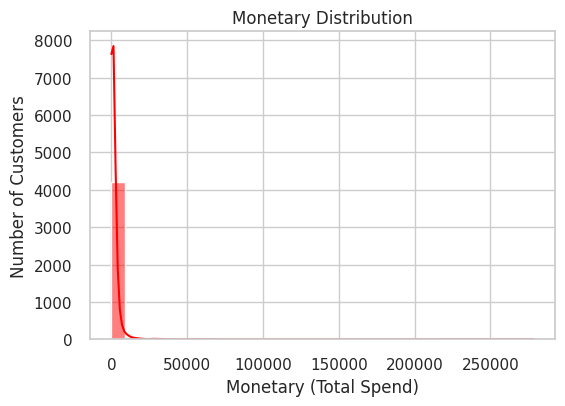

In [139]:
# Monetary
plt.figure(figsize=(6,4))
sns.histplot(x=customer_df['Monetary'], bins=30, kde=True, color='red')  # Changed x and color for Monetary
plt.title('Monetary Distribution')  
plt.xlabel('Monetary (Total Spend)')       
plt.ylabel('Number of Customers')  
plt.show()

**RFM Features**:
- **Recency Distribution**: Most customers made their last purchase recently, within the last 50 days. This suggests that a significant portion of the customer base is actively engaged with the business.
- **Frequency Distribution**: The majority of customers have made very few transactions, typically between 1 to 5. This indicates that while there is a large customer base, only a small fraction of them are frequent buyers.
- **Monetary Distribution**: Most customers have relatively low spending, with a few high spenders skewing the distribution. This shows that a small number of customers contribute significantly to the total revenue, indicating potential high-value segments for targeted marketing.

### Creating "UK" Column

---

- A binary feature indicating whether the customer is located in the United Kingdom (1) or not (0).
- Significant __90%__ of transactions originate from the __United Kingdom__, it may be beneficial to create a binary feature indicating whether a transaction is from the UK or not.    
This approach can simplify the clustering process while preserving essential geographical information, particularly when using algorithms like K-means that are sensitive to the number of features.

In [140]:
# Add the 'UK' column to the customer_df
customer_df['UK'] = df.groupby('CustomerID')['UK'].first().reset_index(drop=True)

## Features for Purchase Metrics:

*Extrac the data and create new columns for more accurate segmentation and analysis.*   
These features enhance customer profiles, enabling more accurate segmentation and analysis.

---

- **`Total_Product`**: column represents the total `Quantity` of products purchased by each customer. 
    - This metric provides insight into the volume of products a customer buys, helping to understand their buying behavior and engagement level. 
    - It’s particularly useful for identifying high-volume customers who may contribute significantly to overall sales and can be targeted for retention and loyalty programs.
    
    
- **`Avg_Price`**: column calculates the average price per transaction for each customer. 
    - This metric offers a view into the typical spending behavior of a customer during each purchase. 
    - It’s important for understanding how much a customer typically spends in one transaction, which can guide personalized marketing efforts and pricing strategies.


- **`Unique_Products_Num`**: column represents the number of distinct products purchased by each customer, measured by the unique `StockCode` values. 
    - This metric helps to understand the diversity of a customer’s purchases, indicating how many different products a customer is interested in. 
    - It’s valuable for identifying customer preferences and can be used to tailor marketing strategies and product recommendations accordingly.


In [141]:
# Extract the total number of products purchased for each customer 
customer_df['Total_Product'] = df.groupby('CustomerID')['Quantity'].sum().reset_index(drop=True)

# Calculate the average transaction  price for each customer 
customer_df['Avg_Price'] = df.groupby('CustomerID')['Total_Price'].sum().values / df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(drop=True)

# Calculate the number of unique products purchased by each customer
customer_df['Unique_Products_Num'] = df.groupby('CustomerID')['StockCode'].nunique().reset_index(drop=True)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num
1,12347,1,7,4310.00,0,2458,615.714286,103
2,12348,74,4,1437.24,0,2332,359.310000,21
3,12349,18,1,1457.55,0,630,1457.550000,72
4,12350,309,1,294.40,0,196,294.400000,16
5,12352,35,8,1265.41,0,463,158.176250,57


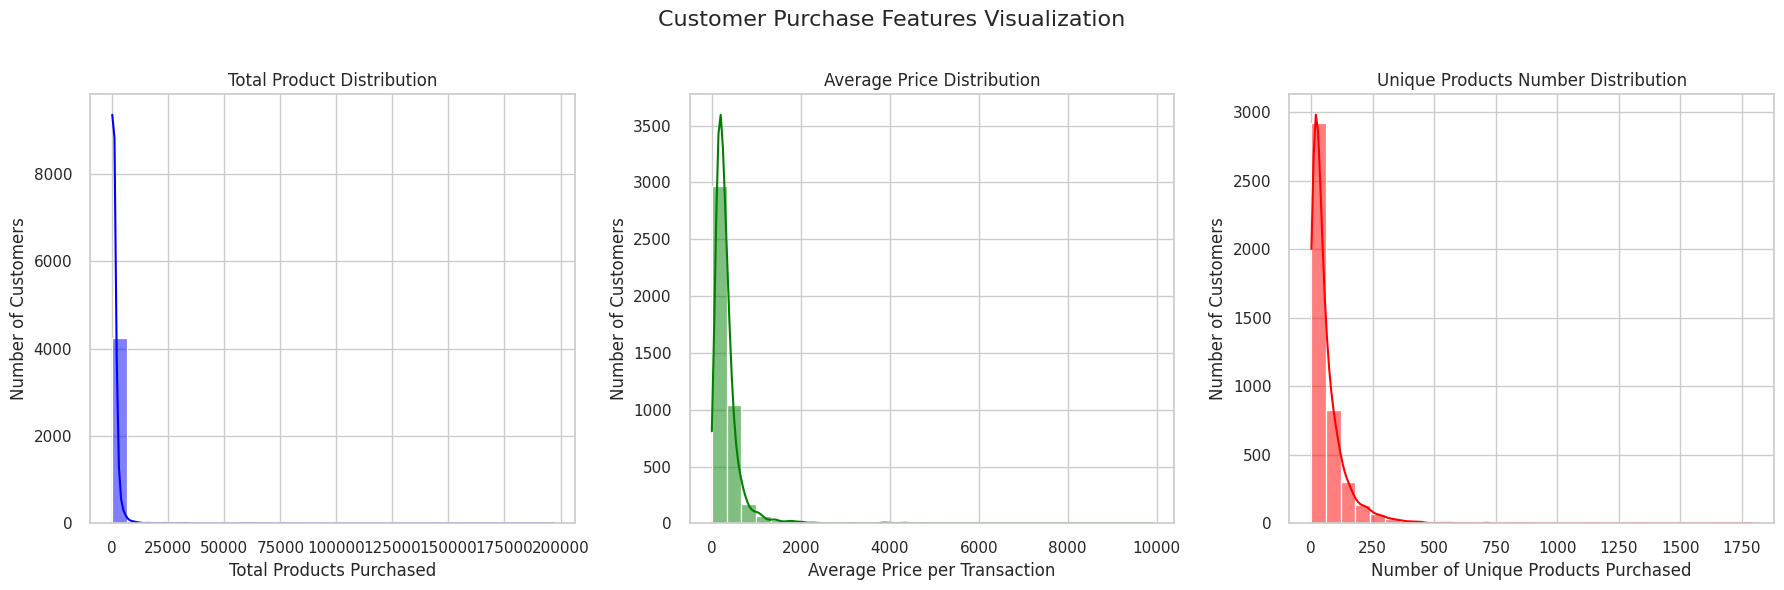

In [142]:
# Set up the figure and the axes (1 row, 3 columns of subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Purchase Features Visualization', fontsize=16)

# Total Product plot
sns.histplot(ax=axes[0], x=customer_df['Total_Product'], bins=30, kde=True, color='blue')
axes[0].set_title('Total Product Distribution')
axes[0].set_xlabel('Total Products Purchased')
axes[0].set_ylabel('Number of Customers')

# Average Price plot
sns.histplot(ax=axes[1], x=customer_df['Avg_Price'], bins=30, kde=True, color='green')
axes[1].set_title('Average Price Distribution')
axes[1].set_xlabel('Average Price per Transaction')
axes[1].set_ylabel('Number of Customers')

# Unique Products Number plot
sns.histplot(ax=axes[2], x=customer_df['Unique_Products_Num'], bins=30, kde=True, color='red')
axes[2].set_title('Unique Products Number Distribution')
axes[2].set_xlabel('Number of Unique Products Purchased')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


1. **Total Products Purchased:** The majority of customers purchase a relatively small number of products, with a few customers making very large purchases. This suggests a potential for identifying high-volume customers who might be particularly valuable for targeted marketing.

2. **Average Price per Transaction:** Most customers tend to spend within a lower price range on average, with a sharp decline in the number of customers as the average price increases. This could indicate different customer segments based on spending behavior.

3. **Unique Products Purchased:** Most customers purchase a limited variety of products, but there are outliers who buy a much broader range of items. This could help identify diverse purchasing behaviors, possibly indicating more engaged or varied customer profiles.

## Features for Customer Shopping Patterns:

*In this step, we focus on identifying customer shopping patterns and behaviors.   
These features will reveal when customers prefer to shop, which is essential for tailoring their shopping experience.*

---

In [143]:
# Extract date-time from InvoiceDate
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day_Of_Week'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceDay'] = df['InvoiceDate'].dt.date
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

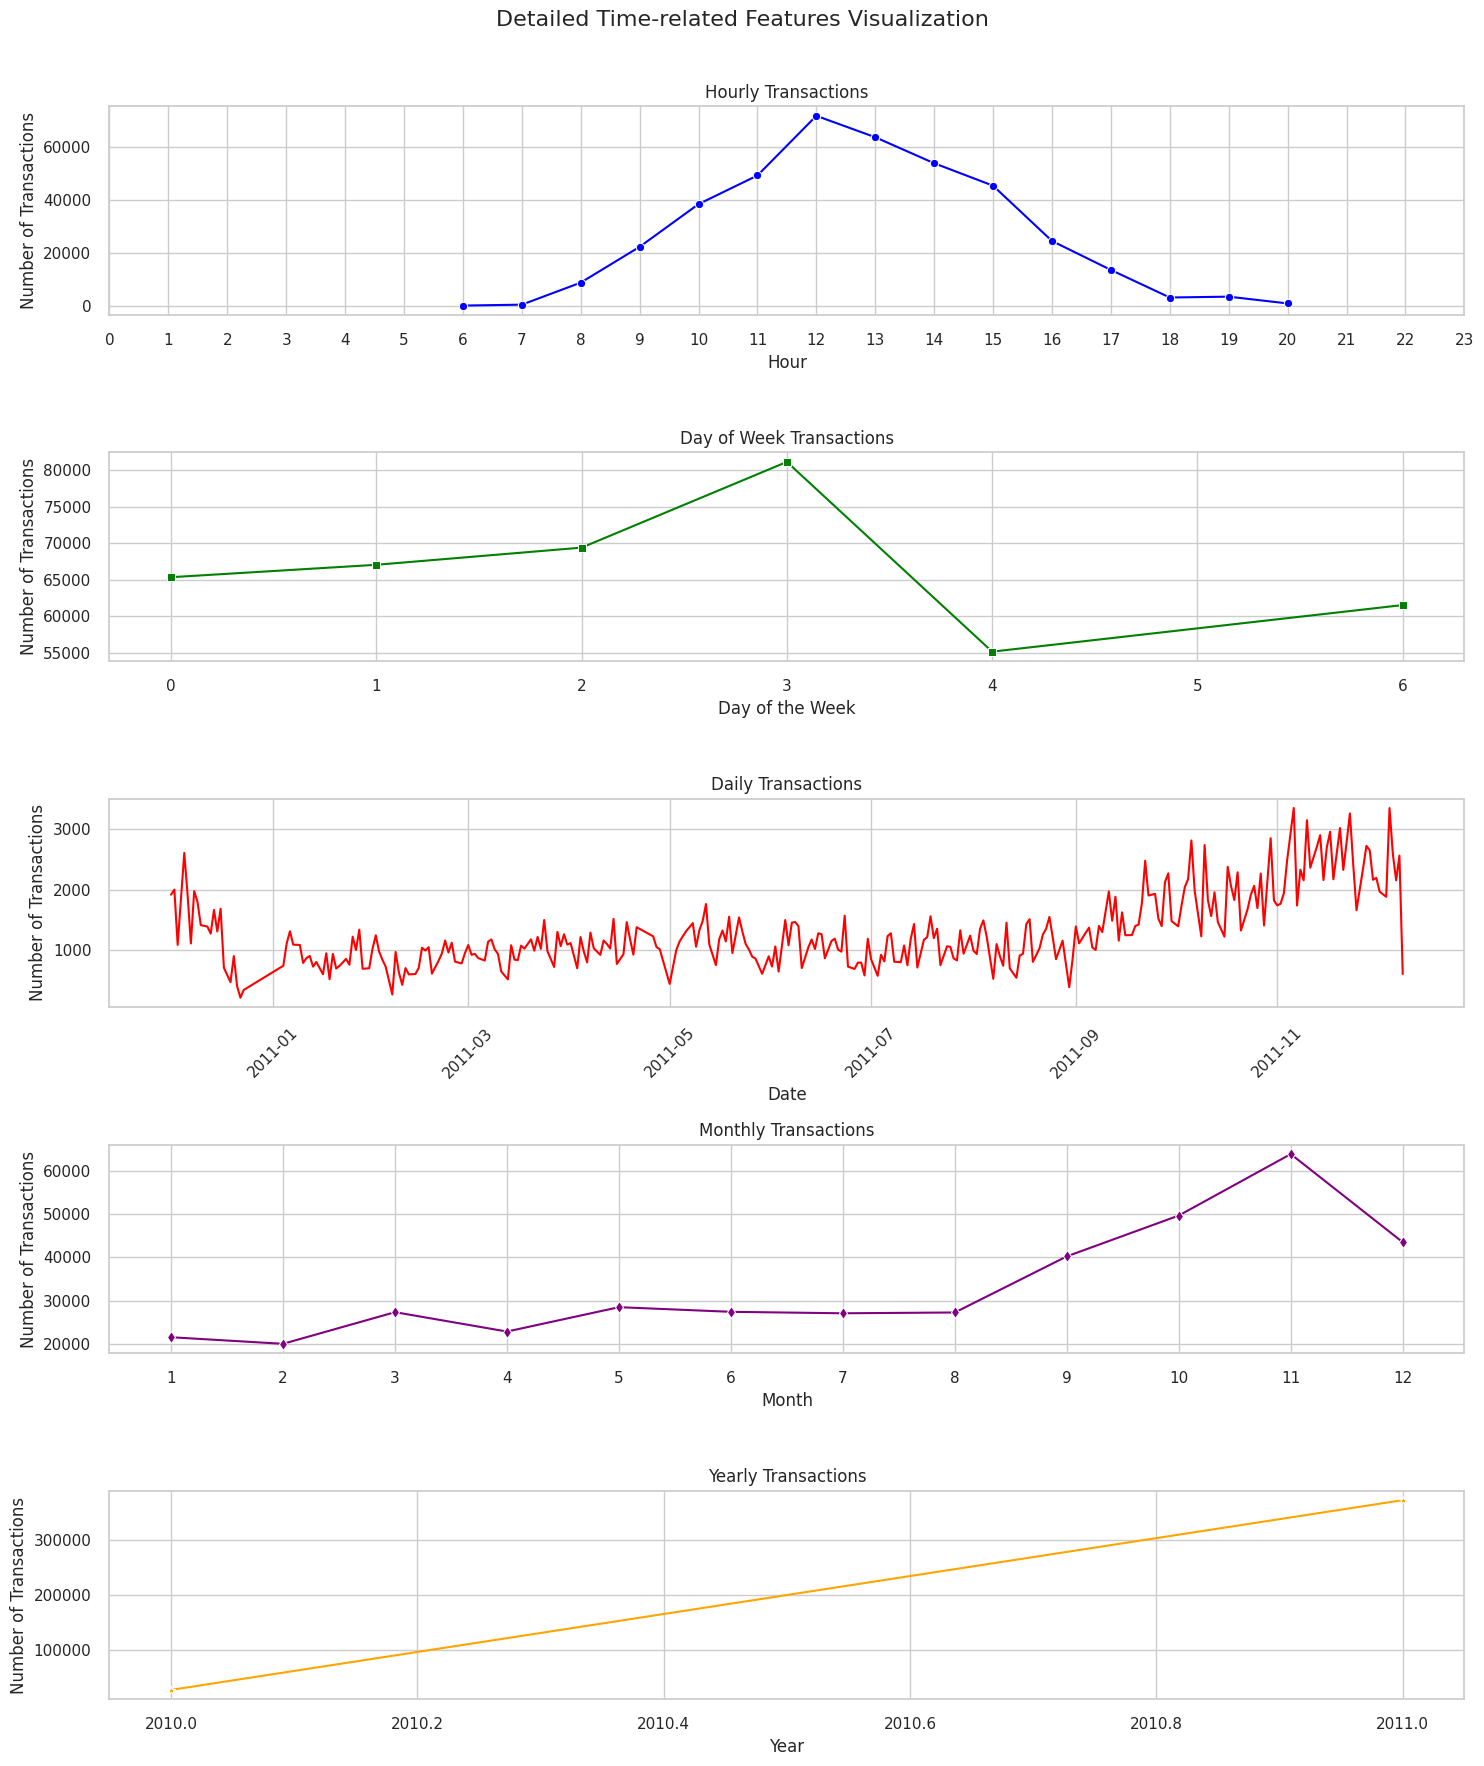

In [144]:
# Set up the figure and the axes (5 rows, 1 column of subplots)
fig, axes = plt.subplots(5, 1, figsize=(15, 18))
fig.suptitle('Detailed Time-related Features Visualization', fontsize=16)

# Hour plot
sns.lineplot(ax=axes[0], x=df['Hour'].value_counts().sort_index().index, 
             y=df['Hour'].value_counts().sort_index().values, 
             color='blue', marker='o')
axes[0].set_title('Hourly Transactions')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(24))  # Show all hours

# Day of the Week plot
sns.lineplot(ax=axes[1], x=df['Day_Of_Week'].value_counts().sort_index().index, 
             y=df['Day_Of_Week'].value_counts().sort_index().values, 
             color='green', marker='s')
axes[1].set_title('Day of Week Transactions')
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(range(7))  # Show all days of the week

# Invoice Day plot
sns.lineplot(ax=axes[2], x=df['InvoiceDay'].value_counts().sort_index().index, 
             y=df['InvoiceDay'].value_counts().sort_index().values, 
             color='red')
axes[2].set_title('Daily Transactions')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Number of Transactions')
axes[2].tick_params(axis='x', rotation=45)  # Rotate dates for better readability

# Month plot
sns.lineplot(ax=axes[3], x=df['Month'].value_counts().sort_index().index, 
             y=df['Month'].value_counts().sort_index().values, 
             color='purple', marker='d')
axes[3].set_title('Monthly Transactions')
axes[3].set_xlabel('Month')
axes[3].set_ylabel('Number of Transactions')
axes[3].set_xticks(range(1, 13))  # Show all months

# Year plot
sns.lineplot(ax=axes[4], x=df['Year'].value_counts().sort_index().index, 
             y=df['Year'].value_counts().sort_index().values, 
             color='orange', marker='*')
axes[4].set_title('Yearly Transactions')
axes[4].set_xlabel('Year')
axes[4].set_ylabel('Number of Transactions')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Time-related Features Visualization**:
- **Hourly Transactions** peak between 12:00-14:00, indicating a high customer activity during midday.
- **Day of the Week Transactions** show a significant spike on Wednesdays and a drop on Sundays.
- **Daily Transactions** increase sharply towards the end of 2011, likely due to holiday shopping.
- **Monthly Transactions** reach their highest in November, possibly due to Black Friday and year-end sales.
- **Yearly Transactions** show consistent growth, indicating overall business expansion.

These patterns can be used to create features for clustering:
- **Peak Shopping Hours**: Segment customers based on the time of day they prefer to shop.
- **Weekly Shopping Preferences**: Group customers by their preferred day of the week for making purchases.
- **Seasonal Buyers**: Identify customers who are more active during specific months or holidays.
- **Purchase Trends Over Time**: Analyze customers' spending trends over the year to understand their shopping frequency and predict future behavior.

By incorporating these features, clustering can more accurately reflect customer behavior and preferences, allowing for better-targeted marketing strategies.


### **Creating "Favorite_Day" and "Favorite_Hour" and "Average_Days_Between_Purchases" Columns;**

---

- **`Favorite_Day`**: column represents the day of the week on which each customer most frequently makes purchases.
    - This metric helps identify the preferred shopping days of customers, offering insights into their weekly shopping habits.
    - It is useful for optimizing marketing campaigns and promotions on specific days to engage customers when they are most likely to shop.


- **`Favorite_Hour`**: column indicates the hour of the day during which each customer most frequently makes purchases.
    - This metric provides insights into the time of day customers prefer to shop, helping to tailor marketing strategies and operational hours to match peak shopping times.
    - It can be particularly useful for targeting customers with time-sensitive offers and promotions.


- **`Average_Days_Between_Purchases`**: column represents the average number of days between consecutive purchases for each customer.
    - This metric provides insight into the frequency of customer engagement, helping to understand their buying cycle.
    - It’s useful for predicting future purchases and for designing personalized re-engagement strategies to reduce the time between purchases.



In [145]:
# Calculate the average number of days between consecutive purchases
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Avg_Days_Between_Buys'}, inplace=True)

# Find the favorite shopping day of the week
favorite_shopping_day = df.groupby(['CustomerID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]

# Find the favorite shopping hour of the day
favorite_shopping_hour = df.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]

# Merge the new features into the customer_df dataframe
customer_df = pd.merge(customer_df, average_days_between_purchases, on='CustomerID', how='left')
customer_df = pd.merge(customer_df, favorite_shopping_day, on='CustomerID', how='left')
customer_df = pd.merge(customer_df, favorite_shopping_hour, on='CustomerID', how='left')

# Rename columns to maintain consistency
customer_df.rename(columns={'Day_Of_Week': 'Favorite_Day', 'Hour': 'Favorite_Hour'}, inplace=True)

# Display the first few rows of the customer_df dataframe
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Day,Favorite_Hour
0,12347,1,7,4310.00,0,2458,615.714286,103,2.016575,1,14
1,12348,74,4,1437.24,0,2332,359.310000,21,10.884615,3,19
2,12349,18,1,1457.55,0,630,1457.550000,72,0.000000,0,9
3,12350,309,1,294.40,0,196,294.400000,16,0.000000,2,16
4,12352,35,8,1265.41,0,463,158.176250,57,3.132530,1,14


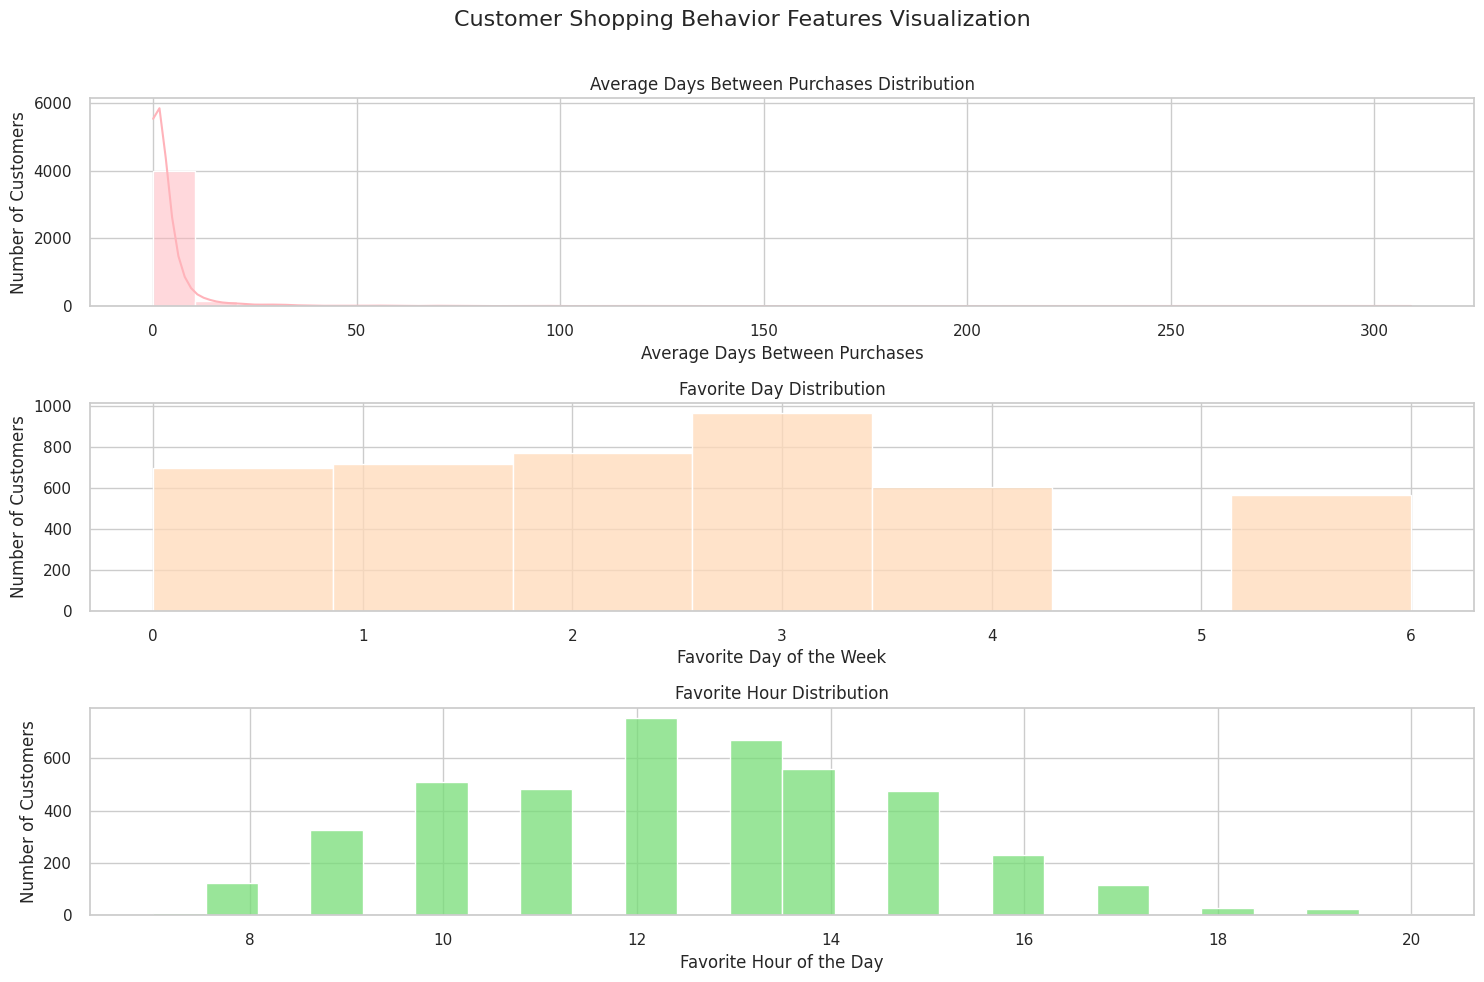

In [146]:
# Set up the figure and the axes (3 rows, 1 column of subplots)
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Customer Shopping Behavior Features Visualization', fontsize=16)

# Average Days Between Purchases plot
sns.histplot(ax=axes[0], x=customer_df['Avg_Days_Between_Buys'], bins=30, kde=True, color='#FFB3BA')
axes[0].set_title('Average Days Between Purchases Distribution')
axes[0].set_xlabel('Average Days Between Purchases')
axes[0].set_ylabel('Number of Customers')

# Favorite Day plot
sns.histplot(ax=axes[1], x=customer_df['Favorite_Day'], bins=7, kde=False,color='#FFDAB9')
axes[1].set_title('Favorite Day Distribution')
axes[1].set_xlabel('Favorite Day of the Week')
axes[1].set_ylabel('Number of Customers')

# Favorite Hour plot
sns.histplot(ax=axes[2], x=customer_df['Favorite_Hour'], bins=24, kde=False, color='#77DD77')
axes[2].set_title('Favorite Hour Distribution')
axes[2].set_xlabel('Favorite Hour of the Day')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### **"Monthly_Spending_Mean" and "Monthly_Spending_Std" Columns;**

---

- **`Monthly_Spending_Mean`**: column represents the average amount of money spent by each customer per month.
    - This metric provides insight into the customer’s monthly spending behavior, helping to understand their overall value to the business.
    - It’s useful for identifying high-value customers and for planning targeted marketing and budgeting strategies based on consistent spending patterns.


- **`Monthly_Spending_Std`**: column indicates the standard deviation of a customer’s monthly spending, showing how much their spending varies month to month.
    - This metric helps identify customers with inconsistent spending habits, which may be influenced by seasonal trends or other factors.
    - It’s useful for understanding variability in customer behavior and for creating more personalized offers that match their spending patterns.


In [147]:
# Calculate the mean and standard deviation of monthly spending for each customer
monthly_spending = df.groupby(['CustomerID', 'Year', 'Month'])['Total_Price'].sum().reset_index()

# Group by CustomerID to calculate the mean and std for each customer
monthly_spending_mean_std = monthly_spending.groupby('CustomerID')['Total_Price'].agg(['mean', 'std']).fillna(0).reset_index()

# Merge the results back into customer_df using CustomerID
customer_df = pd.merge(customer_df, monthly_spending_mean_std, on='CustomerID', how='left')

# Rename the columns
customer_df.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

# Display the first few rows of the customer_df dataframe
customer_df.head()


,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Day,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std
0,12347,1,7,4310.00,0,2458,615.714286,103,2.016575,1,14,615.714286,341.070789
1,12348,74,4,1437.24,0,2332,359.310000,21,10.884615,3,19,359.310000,203.875689
2,12349,18,1,1457.55,0,630,1457.550000,72,0.000000,0,9,1457.550000,0.000000
3,12350,309,1,294.40,0,196,294.400000,16,0.000000,2,16,294.400000,0.000000
4,12352,35,8,1265.41,0,463,158.176250,57,3.132530,1,14,316.352500,134.700629


### **Creating "Spending_Trend" Column;**

---

- **`Spending_Trend`**: column calculates the trend (slope) of a customer’s spending over time, indicating whether their spending is increasing or decreasing.
    - This metric provides insight into long-term customer engagement and value, helping to identify trends in customer behavior.
    - It’s particularly useful for targeting customers whose spending is declining with retention efforts or re-engagement campaigns.
    



In [148]:
# Calculate the spending trend (slope) for each customer over time
def calculate_trend(spend_data):
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    else:
        return 0

# Apply the trend calculation to each customer's spending data
spending_trend = monthly_spending.groupby('CustomerID')['Total_Price'].apply(calculate_trend).reset_index()
customer_df = pd.merge(customer_df, spending_trend, on='CustomerID', how='left')

# Rename the column
customer_df.rename(columns={'Total_Price': 'Spending_Trend'}, inplace=True)

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Day,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347,1,7,4310.00,0,2458,615.714286,103,2.016575,1,14,615.714286,341.070789,4.486071
1,12348,74,4,1437.24,0,2332,359.310000,21,10.884615,3,19,359.310000,203.875689,-100.884000
2,12349,18,1,1457.55,0,630,1457.550000,72,0.000000,0,9,1457.550000,0.000000,0.000000
3,12350,309,1,294.40,0,196,294.400000,16,0.000000,2,16,294.400000,0.000000,0.000000
4,12352,35,8,1265.41,0,463,158.176250,57,3.132530,1,14,316.352500,134.700629,9.351000


### **Creating "Cancel_Frequency" and "Cancel_Rate" Columns;**

---

- **`Cancellation_Frequency`**: column represents the total number of cancelled transactions for each customer.
    - This metric helps identify customers who frequently cancel their orders, which could indicate dissatisfaction or other issues.
    - It is useful for addressing potential customer service problems and improving overall customer satisfaction.


- **`Cancellation_Rate`**: column calculates the ratio of cancelled transactions to total transactions for each customer.
    - This metric provides a percentage that indicates the likelihood of a customer cancelling their orders.
    - It is particularly useful for monitoring customer satisfaction and identifying patterns that may require intervention to reduce cancellation rates.

In [149]:
# Calculate the number of cancelled transactions for each customer
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancel_frequency = cancelled_transactions.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancel_frequency.rename(columns={'InvoiceNo': 'Cancel_Frequency'}, inplace=True)

# Merge the Cancellation Frequency data into the customer_data dataframe
customer_df = pd.merge(customer_df, cancel_frequency, on='CustomerID', how='left')
customer_df['Cancel_Frequency'].fillna(0, inplace=True)

# Calculate the Cancellation Rate
customer_df['Cancel_Rate'] = customer_df['Cancel_Frequency'] / customer_df['Frequency']

customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Day,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Cancel_Frequency,Cancel_Rate
0,12347,1,7,4310.00,0,2458,615.714286,103,2.016575,1,14,615.714286,341.070789,4.486071,0.0,0.000
1,12348,74,4,1437.24,0,2332,359.310000,21,10.884615,3,19,359.310000,203.875689,-100.884000,0.0,0.000
2,12349,18,1,1457.55,0,630,1457.550000,72,0.000000,0,9,1457.550000,0.000000,0.000000,0.0,0.000
3,12350,309,1,294.40,0,196,294.400000,16,0.000000,2,16,294.400000,0.000000,0.000000,0.0,0.000
4,12352,35,8,1265.41,0,463,158.176250,57,3.132530,1,14,316.352500,134.700629,9.351000,1.0,0.125


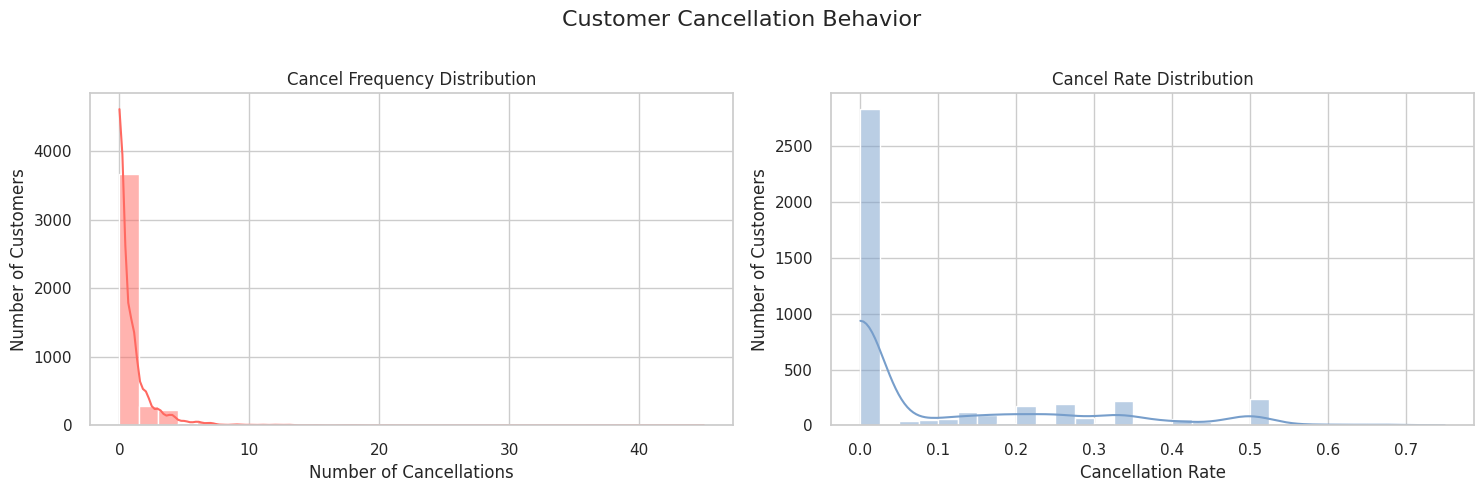

In [150]:
# Set up the figure and the axes (2 rows, 1 column of subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Customer Cancellation Behavior', fontsize=16)

# Cancel Frequency plot
sns.histplot(ax=axes[0], x=customer_df['Cancel_Frequency'], bins=30, kde=True, color='#FF6961')
axes[0].set_title('Cancel Frequency Distribution')
axes[0].set_xlabel('Number of Cancellations')
axes[0].set_ylabel('Number of Customers')

# Cancel Rate plot
sns.histplot(ax=axes[1], x=customer_df['Cancel_Rate'], bins=30, kde=True, color='#779ECB')
axes[1].set_title('Cancel Rate Distribution')
axes[1].set_xlabel('Cancellation Rate')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### **Final DataFrame: `customer_df`:**   

---

|        | **Feature**                | **Description**                                                                                       |
|--------|----------------------------|-------------------------------------------------------------------------------------------------------|
| 1      | **CustomerID**              | Unique identifier for each customer.                                                                  |
| 2      | **Recency**                 | The number of days since the customer's last purchase. Lower values indicate more recent purchases.   |
| 3      | **Frequency**               | The total number of transactions made by the customer. Higher values suggest frequent engagement.     |
| 4      | **Monetary**                | The total monetary value spent by the customer. Higher values indicate more spending by the customer. |
| 5      | **Total_Product**           | The total quantity of products purchased by the customer.                                             |
| 6      | **Avg_Price**               | The average price per transaction for the customer.                                                   |
| 7      | **Unique_Products_Num**     | The number of unique products purchased by the customer.                                              |
| 8      | **Average_Days_Between_Purchases** | The average number of days between the customer's purchases. Lower values suggest frequent purchases. |
| 9      | **Favorite_Day**            | The day of the week when the customer most frequently makes purchases.                                |
| 10     | **Favorite_Hour**           | The hour of the day when the customer most frequently makes purchases.                                |
| 11     | **Monthly_Spending_Mean**   | The average monthly spending of the customer.                                                         |
| 12     | **Monthly_Spending_Std**    | The standard deviation of the customer's monthly spending, indicating variability in spending.        |
| 13     | **Spending_Trend**          | The trend of the customer's spending over time. Positive values indicate increasing spending trends.  |
| 14     | **Cancel_Frequency**        | The total number of transactions canceled by the customer.                                            |
| 15     | **Cancel_Rate**             | The rate of canceled transactions relative to the total transactions made by the customer.            |
| 16     | **UK**                      | A binary feature indicating whether the customer is located in the United Kingdom (1) or not (0).     |
|        |                             |                                                                                                       |


---


## Outlier Analysis:

1. **Monetary**: There are significant outliers where certain customers have spent much more than the majority. 
2. **Total_Product**: Some customers have purchased a vastly larger number of products compared to the rest, indicating outliers in the number of products purchased.
3. **Avg_Price**: There are a few outliers where the average price per transaction is much higher than the general trend.
4. **Monthly_Spending_Mean**: Some customers have a much higher average monthly spending compared to others, marking them as outliers.
5. **Spending_Trend**: There are noticeable outliers where the spending trend (slope) is either significantly positive or negative, indicating rapidly increasing or decreasing spending behavior.
6. **Cancel_Frequency**: While most customers rarely cancel orders, a few have a much higher number of cancellations, making them outliers.
7. **Cancel_Rate**: Similar to cancel frequency, there are outliers with a higher cancel rate, indicating that some customers cancel a large proportion of their transactions.


These features contain notable outliers, which could impact the analysis and modeling if not properly handled.   
In K-means clustering, the algorithm's sensitivity to data scale and outliers can affect centroid positions and lead to incorrect cluster assignments.  However,this project focuses on understanding customer behavior through K-means clustering, it's wiser to address outliers after seeng the model performance.   
At this step, removing outliers could result in losing valuable information important for customer segmentation later.

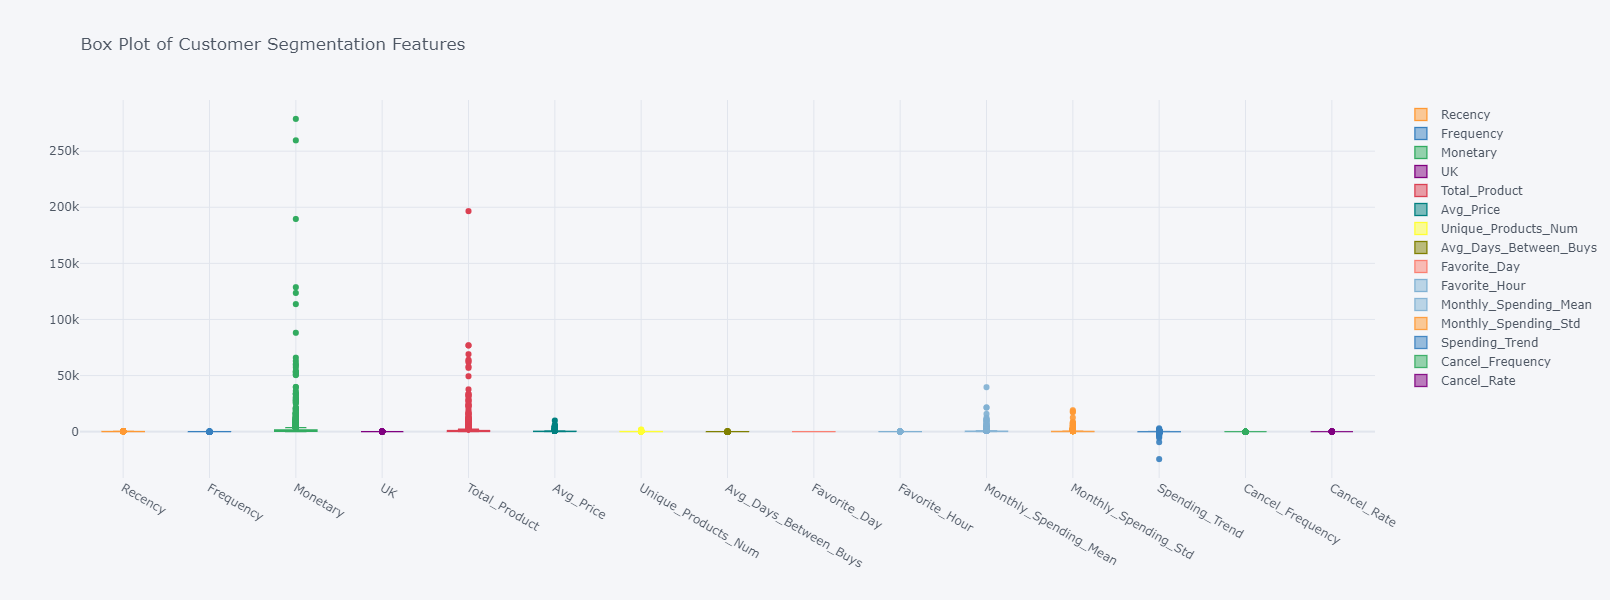

In [151]:
import cufflinks as cf  
cf.go_offline()
customer_df.iloc[:,1:].iplot(kind="box",title="Box Plot of Customer Segmentation Features",boxpoints='outliers', dimensions=(1400, 600))

In [152]:
# Calculate skewness 

# A skewness of 0 means the distribution is perfectly symmetrical.
# Positive skewness indicates a longer tail on the right (right-skewed).
# Negative skewness indicates a longer tail on the left (left-skewed).

skewness = customer_df.skew().reset_index()

# Rename columns for clarity
skewness.columns = ['Feature', 'Skewness']
skewness

,Feature,Skewness
0,CustomerID,0.002239
1,Recency,1.263685
2,Frequency,11.413836
3,Monetary,21.553217
4,UK,-2.730693
5,Total_Product,22.930798
6,Avg_Price,8.866433
7,Unique_Products_Num,6.919959
8,Avg_Days_Between_Buys,14.906169
9,Favorite_Day,0.415549


### Outlier Removal:

1. Apply log transformations to reduce skewness.
2. Handle negative skewness with an inverse log transformation.
3. Remove outliers using the `remove_outliers_iqr` function.

In [153]:
# CREATE "CLEANED_DF"

# Define the remove_outliers_iqr function
def remove_outliers_iqr(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# List of columns to apply log transformation (to handle positive skewness)
log_transform_columns = ['Frequency', 'Monetary', 'Total_Product', 
                         'Avg_Price', 'Unique_Products_Num', 
                         'Avg_Days_Between_Buys', 'Monthly_Spending_Mean', 
                         'Monthly_Spending_Std', 'Cancel_Frequency', 'Cancel_Rate']

# Apply log transformation
for col in log_transform_columns:
    customer_df[col] = np.log1p(customer_df[col])  # log1p is used to handle zero values

# Handle negative skewness for 'Spending_Trend'
customer_df['Spending_Trend'] = np.log1p(-customer_df['Spending_Trend'])

# Now remove outliers using the IQR method
cleaned_df = remove_outliers_iqr(customer_df, log_transform_columns)

# Display the DataFrame after transformation and outlier removal
print(cleaned_df.head())

  CustomerID  Recency  Frequency  Monetary  UK  Total_Product  Avg_Price  \
0      12347        1   2.079442  8.368925   0       7.807510   6.424406   
1      12348       74   1.609438  7.271175   0       7.754910   5.886965   
3      12350      309   0.693147  5.688330   0       5.283204   5.688330   
4      12352       35   2.197225  7.143941   0       6.139885   5.070012   
5      12353      203   0.693147  4.499810   0       3.044522   4.499810   

   Unique_Products_Num  Avg_Days_Between_Buys  Favorite_Day  Favorite_Hour  \
0             4.644391               1.104122             1             14   
1             3.091042               2.475245             3             19   
3             2.833213               0.000000             2             16   
4             4.060443               1.418890             1             14   
5             1.609438               0.000000             3             17   

   Monthly_Spending_Mean  Monthly_Spending_Std  Spending_Trend  \
0       

### "NaN" Values;

The missing values in the dataset were filled with 0 because they typically arise from customers who either made only one purchase or did not engage in certain behaviors (e.g., no repeated purchases for calculating average days between purchases). These are not traditional "missing" values due to data issues but rather valid cases where no meaningful value exists.   
For example, if a customer has only made one purchase, it is logical to assign 0 to "Average_Days_Between_Purchases" as there are no consecutive purchases to calculate a gap. Similarly, 0 was used for other metrics like spending trends or cancellation frequency to indicate no activity or engagement in that category. Filling these values with 0 helps ensure the dataset remains clean and consistent for analysis without introducing artificial biases.

In [154]:
customer_df.isna().sum()

CustomerID                  0
Recency                     0
Frequency                   0
Monetary                    0
UK                          0
Total_Product               0
Avg_Price                   0
Unique_Products_Num         0
Avg_Days_Between_Buys      69
Favorite_Day                0
Favorite_Hour               0
Monthly_Spending_Mean       0
Monthly_Spending_Std        0
Spending_Trend           1318
Cancel_Frequency            0
Cancel_Rate                 0
dtype: int64

In [155]:
customer_df.fillna(0, inplace=True)
customer_df.isna().sum()

CustomerID               0
Recency                  0
Frequency                0
Monetary                 0
UK                       0
Total_Product            0
Avg_Price                0
Unique_Products_Num      0
Avg_Days_Between_Buys    0
Favorite_Day             0
Favorite_Hour            0
Monthly_Spending_Mean    0
Monthly_Spending_Std     0
Spending_Trend           0
Cancel_Frequency         0
Cancel_Rate              0
dtype: int64

## Correlation Matrix

Based on the heatmap, several pairs of variables exhibit strong correlations:

- **`Monetary` and `Total_Product`** show a very high correlation, suggesting that customers who spend more tend to purchase a larger quantity of products.
- **`Monetary` and `Monthly_Spending_Mean`** are also highly correlated, indicating that customers with higher total spendings have a higher average monthly expenditure.
- **`Frequency` and `Cancel_Frequency`** demonstrate a strong positive correlation, implying that customers who make frequent purchases are also more likely to cancel transactions.
- **`Monthly_Spending_Mean` and `Monthly_Spending_Std`** show a notable correlation, suggesting that customers with higher average monthly spending also exhibit more variability in their spending habits.

These correlations indicate potential multicollinearity, which could impact the stability of the clustering process.    
To address this, it might be beneficial to apply dimensionality reduction techniques, such as **PCA**, to reduce the multicollinearity among these features.    
This will help ensure that the clustering results are more reliable and less influenced by redundant information.

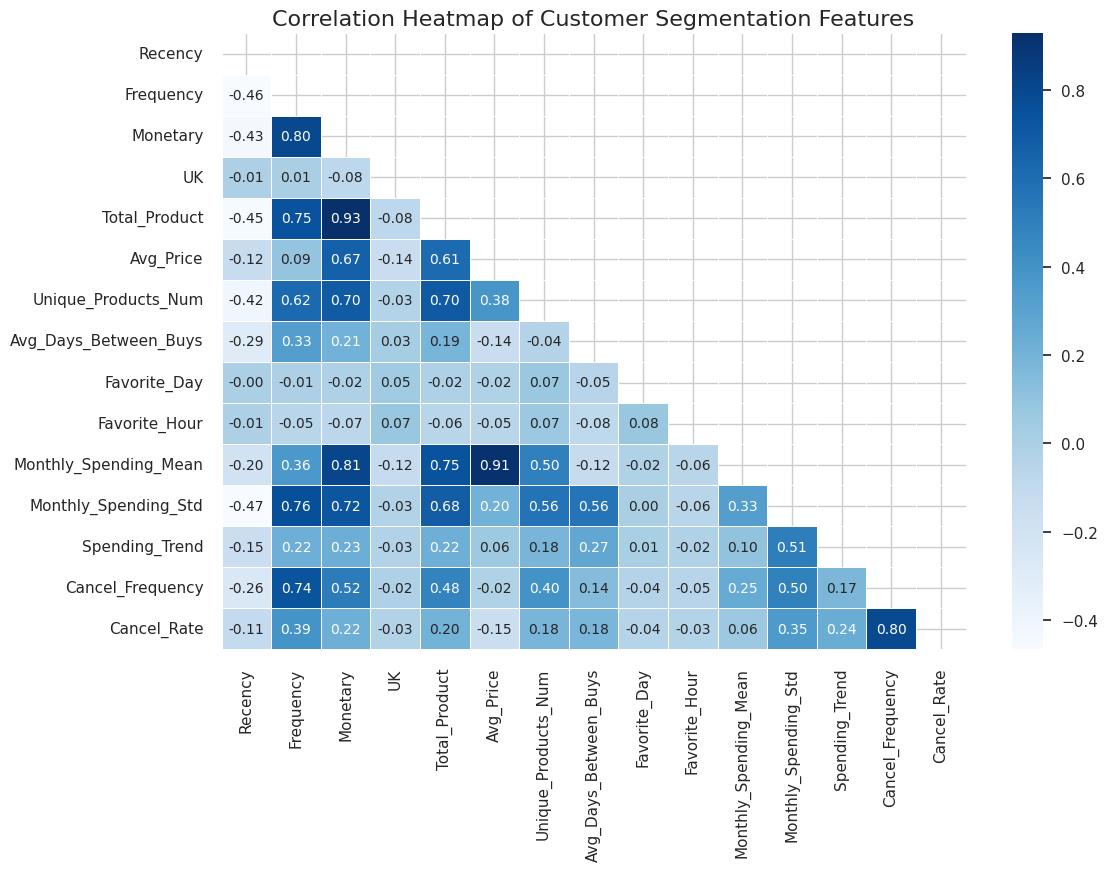

In [156]:
# Calculate the correlation matrix
corr_matrix = customer_df.drop(columns=['CustomerID']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, annot_kws={"size": 10}, mask=np.triu(corr_matrix))
plt.title('Correlation Heatmap of Customer Segmentation Features', fontsize=16)
plt.show()

<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;"> Data Preprocessing </p> 


Before proceeding with clustering and dimensionality reduction, it's crucial to scale our features. This is particularly important for distance-based methods like K-means and PCA:

- **K-means Clustering:** Since K-means relies on measuring the distance between data points to form clusters, unscaled features with larger values could disproportionately affect the clustering results, potentially leading to inaccurate groupings.
- **PCA:** PCA identifies the directions of maximum variance in the data. If the features are not scaled, those with larger values might dominate the principal components, potentially obscuring important patterns in the data.

<a id="setup"></a>
## <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 8px;"> Scaling the Data</p> 


To prepare the data for PCA and K-means clustering, **StandardScaler** will be used to ensure that the features have a mean of 0 and a standard deviation of 1.   
However, certain features like `CustomerID` (customer identifier), `UK` (binary feature with values 1 or 0), and `Favorite_Day` (categorical feature represented by integers from 1 to 7) will not be scaled, as they are either identifiers, binary, or categorical, and scaling them is not necessary.


### df With Outliers: "customer_df" Scale

In [157]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,UK,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Day,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Cancel_Frequency,Cancel_Rate
0,12347,1,2.079442,8.368925,0,7.807510,6.424406,4.644391,1.104122,1,14,6.424406,5.835018,0.000000,0.000000,0.000000
1,12348,74,1.609438,7.271175,0,7.754910,5.886965,3.091042,2.475245,3,19,5.886965,5.322403,4.623835,0.000000,0.000000
2,12349,18,0.693147,7.285198,0,6.447306,7.285198,4.290459,0.000000,0,9,7.285198,0.000000,-0.000000,0.000000,0.000000
3,12350,309,0.693147,5.688330,0,5.283204,5.688330,2.833213,0.000000,2,16,5.688330,0.000000,-0.000000,0.000000,0.000000
4,12352,35,2.197225,7.143941,0,6.139885,5.070012,4.060443,1.418890,1,14,5.760013,4.910451,0.000000,0.693147,0.117783


In [158]:
# Columns to exclude from scaling
exclude_columns = ['CustomerID', 'UK', 'Favorite_Day']

# Separate the features to be scaled and those to be excluded
features_to_scale = customer_df.drop(columns=exclude_columns)
excluded_features = customer_df[exclude_columns]

# Initialize the scaler and scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

# Combine the scaled features with the excluded features
customer_df_scaled = pd.concat([excluded_features.reset_index(drop=True), pd.DataFrame(scaled_features, columns=features_to_scale.columns)], axis=1)

# Display the first few rows of the scaled DataFrame
customer_df_scaled.head()


,CustomerID,UK,Favorite_Day,Recency,Frequency,Monetary,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Cancel_Frequency,Cancel_Rate
0,12347,0,1,-0.891998,0.873352,1.436481,1.347656,1.241951,0.964025,0.244879,0.656689,0.862513,1.038772,-0.647028,-0.631547,-0.637871
1,12348,0,3,-0.157491,0.231895,0.570349,1.309231,0.531424,-0.411121,1.775923,2.823601,0.210054,0.838551,1.503771,-0.631547,-0.637871
2,12349,0,0,-0.720949,-1.018652,0.581413,0.353995,2.379965,0.650697,-0.988022,-1.510224,1.907522,-1.240312,-0.647028,-0.631547,-0.637871
3,12350,0,2,2.207021,-1.018652,-0.678528,-0.496410,0.268818,-0.639372,-0.988022,1.523454,-0.031090,-1.240312,-0.647028,-0.631547,-0.637871
4,12352,0,1,-0.549899,1.034101,0.469960,0.129416,-0.548633,0.447069,0.596360,0.656689,0.055934,0.677648,-0.647028,0.607698,0.236966


### df Without Outliers: "cleaned_df" Scale

In [159]:
# Columns to exclude from scaling
exclude_columns = ['CustomerID', 'UK', 'Favorite_Day']

# Separate the features to be scaled and those to be excluded
features_to_scale = cleaned_df.drop(columns=exclude_columns)
excluded_features = cleaned_df[exclude_columns]

# Initialize the scaler and scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

# Combine the scaled features with the excluded features
cleaned_df_scaled = pd.concat([excluded_features.reset_index(drop=True), pd.DataFrame(scaled_features, columns=features_to_scale.columns)], axis=1)
cleaned_df_scaled.fillna(0, inplace=True)

# Display the first few rows of the scaled DataFrame
cleaned_df_scaled.head()

,CustomerID,UK,Favorite_Day,Recency,Frequency,Monetary,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Cancel_Frequency,Cancel_Rate
0,12347,0,1,-0.888912,1.065265,1.724365,1.592584,1.519328,1.010236,0.281540,0.642377,1.143871,1.105386,0.000000,-0.582654,-0.572681
1,12348,0,3,-0.139020,0.342548,0.703759,1.547563,0.624275,-0.523055,1.921636,2.826435,0.301081,0.897510,1.177447,-0.582654,-0.572681
2,12350,0,2,2.275017,-1.066420,-0.767851,-0.567986,0.293469,-0.777554,-1.039178,1.516000,-0.010408,-1.260833,-0.864100,-0.582654,-0.572681
3,12352,0,1,-0.539647,1.246379,0.585467,0.165252,-0.736277,0.433829,0.658056,0.642377,0.102001,0.730455,0.000000,0.979660,0.587531
4,12353,0,3,1.186133,-1.066420,-1.872849,-2.484087,-1.685892,-1.985528,-1.039178,1.952812,-1.874192,-1.260833,-0.864100,-0.582654,-0.572681


<a id="setup"></a>
## <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 8px;"> PCA - Principal Component Analysis</p> 

**Why Dimensionality Reduction?**


- **Addressing Multicollinearity**: Dimensionality reduction can help resolve multicollinearity by removing redundant features.
- **Optimized K-means Clustering**: Reducing dimensionality can enhance K-means clustering by focusing on the most relevant patterns, leading to more distinct clusters.
- **Noise Reduction**: Simplifying the dataset by keeping only the essential features can minimize noise, resulting in more accurate clusters.
- **Better Visualization**: Dimensionality reduction allows for easier visualization of customer segments in two or three dimensions, offering clearer insights.
- **Increased Efficiency**: Fewer features reduce computation time, making the clustering process faster and more efficient.

In this step, the focus is on applying dimensionality reduction techniques, starting with PCA (Principal Component Analysis). PCA is chosen because it effectively captures linear relationships and addresses the multicollinearity present in our data, allowing us to reduce the number of features while retaining essential information. It's also computationally efficient, making it a suitable first choice.

PCA will be used across all components and plot the cumulative variance explained to determine the optimal number of components to retain for further analysis.

In [160]:
customer_df_scaled.head()

,CustomerID,UK,Favorite_Day,Recency,Frequency,Monetary,Total_Product,Avg_Price,Unique_Products_Num,Avg_Days_Between_Buys,Favorite_Hour,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Cancel_Frequency,Cancel_Rate
0,12347,0,1,-0.891998,0.873352,1.436481,1.347656,1.241951,0.964025,0.244879,0.656689,0.862513,1.038772,-0.647028,-0.631547,-0.637871
1,12348,0,3,-0.157491,0.231895,0.570349,1.309231,0.531424,-0.411121,1.775923,2.823601,0.210054,0.838551,1.503771,-0.631547,-0.637871
2,12349,0,0,-0.720949,-1.018652,0.581413,0.353995,2.379965,0.650697,-0.988022,-1.510224,1.907522,-1.240312,-0.647028,-0.631547,-0.637871
3,12350,0,2,2.207021,-1.018652,-0.678528,-0.496410,0.268818,-0.639372,-0.988022,1.523454,-0.031090,-1.240312,-0.647028,-0.631547,-0.637871
4,12352,0,1,-0.549899,1.034101,0.469960,0.129416,-0.548633,0.447069,0.596360,0.656689,0.055934,0.677648,-0.647028,0.607698,0.236966


### Optimal Number of Components

In the PCA explained variance plot, we can observe the following key points:

- The first component explains **34%** of the variance.
- The first two components together explain **55%** of the variance.
- By the time we include the first **four components**, we capture **76%** of the total variance.
- After the **fifth component**, the cumulative explained variance reaches approximately **81%**.

The curve starts to flatten after the **fifth component**, indicating diminishing returns in the variance explained by adding more components. This suggests that using the first **five components** strikes a balance between retaining meaningful information and reducing dimensionality. Retaining these components will capture most of the important variance in the dataset, while also simplifying the dataset for further analysis.

In the context of customer segmentation, choosing these components should still allow for effective clustering, as these five components together capture a substantial portion of the variance in customer behavior.   
Therefore, using **five components** would be an optimal choice to maintain both efficiency and accuracy for segmentation tasks.

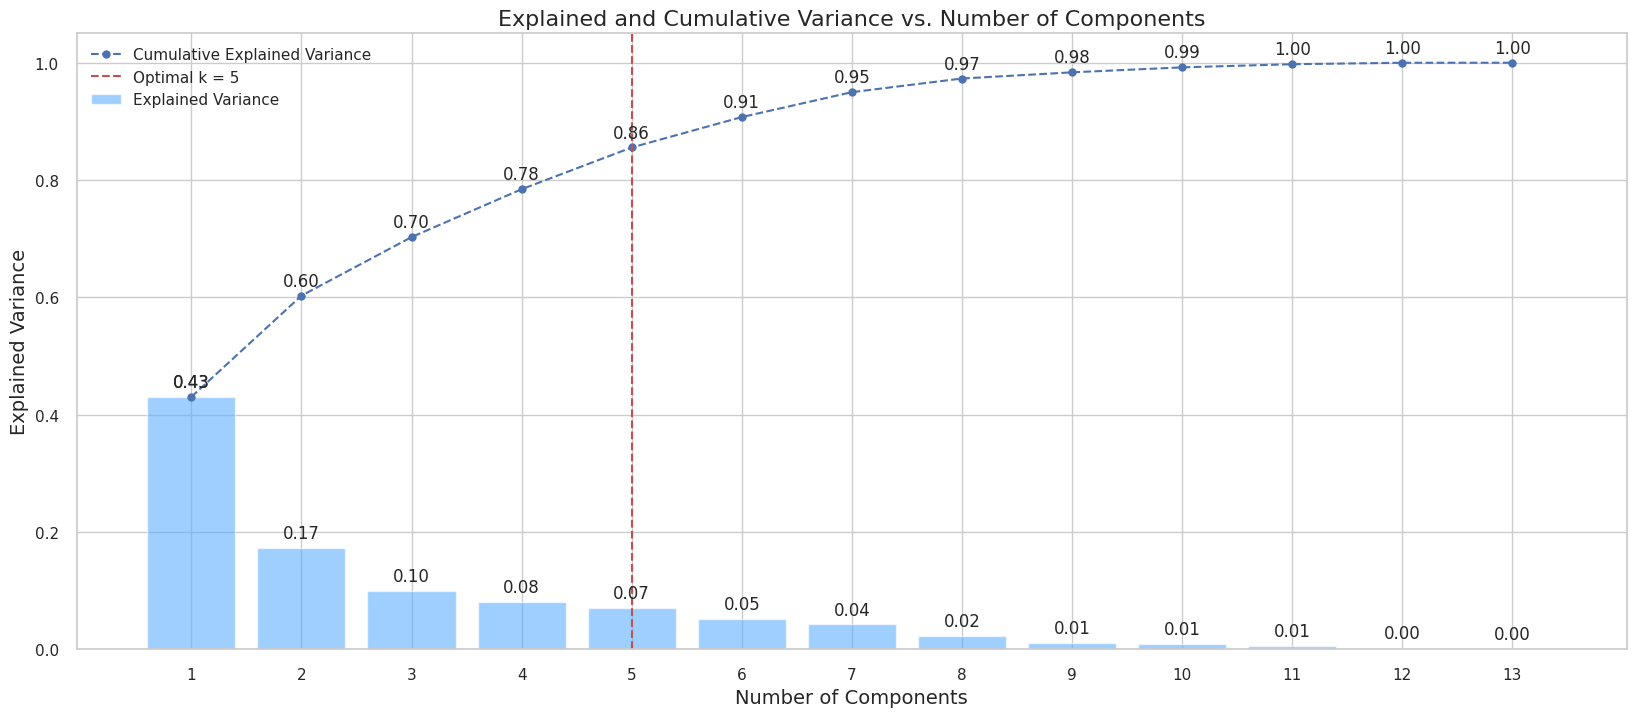

In [161]:
# Setting CustomerID as the index column
customer_df_scaled.set_index('CustomerID', inplace=True)

# Apply PCA
pca = PCA()
pca.fit(customer_df_scaled.drop(columns=['UK', 'Favorite_Day']))

# Calculate explained variance and cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Automatically find the optimal number of components that explain at least 80% of the variance
optimal_k = np.argmax(cumulative_explained_variance >= 0.80) + 1

# Set figure size and style
plt.figure(figsize=(20, 8))
sns.set(style='whitegrid')

# Bar plot for explained variance of each component (light blue color)
plt.bar(range(1,
              len(explained_variance_ratio) + 1),
        explained_variance_ratio,
        alpha=0.6,
        color='#5eafff',
        label='Explained Variance')

# Line plot for cumulative explained variance
plt.plot(range(1,
               len(cumulative_explained_variance) + 1),
         cumulative_explained_variance,
         marker='o',
         linestyle='--',
         color='b',
         label='Cumulative Explained Variance')

# Vertical line for optimal number of components
plt.axvline(optimal_k,
            color='r',
            linestyle='--',
            label=f'Optimal k = {optimal_k}')

# Labels and title
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Explained and Cumulative Variance vs. Number of Components',
          fontsize=16)

# Show all component numbers on the x-axis
plt.xticks(range(1, len(explained_variance_ratio) + 1))

# Show variance values on the bars and line
for i, ev in enumerate(explained_variance_ratio):
    plt.text(i + 1, ev + 0.01, f'{ev:.2f}', ha='center', va='bottom')

for i, cum_ev in enumerate(cumulative_explained_variance):
    plt.text(i + 1, cum_ev + 0.01, f'{cum_ev:.2f}', ha='center', va='bottom')

# Show legend and grid
plt.legend()
plt.grid(True)
plt.show()

### PCA

In [165]:
# Creating a PCA object with 5 components (based on the optimal k from the graph)
pca = PCA(n_components=5)

# Fitting and transforming the original data to the new PCA dataframe
pca_df = pca.fit_transform(customer_df_scaled.drop(columns=['UK', 'Favorite_Day']))

# Creating a new dataframe from the PCA results, with columns labeled PC1, PC2, etc.
pca_df = pd.DataFrame(pca_df, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Adding the CustomerID index back to the new PCA dataframe
pca_df.index = customer_df_scaled.index

pca_df.head()

,PC1,PC2,PC3,PC4,PC5
CustomerID,,,,,
12347,2.445672,-1.544714,0.869512,1.056990,-0.669380
12348,1.286523,0.081357,2.079775,2.041112,1.948141
12349,0.551852,-3.533712,-0.107614,-1.285852,-0.720785
12350,-2.477854,-1.485244,-1.039620,0.671200,1.208640
12352,1.184244,0.868495,-0.178554,0.952804,-0.738375


### Correlation Between PCA and Features

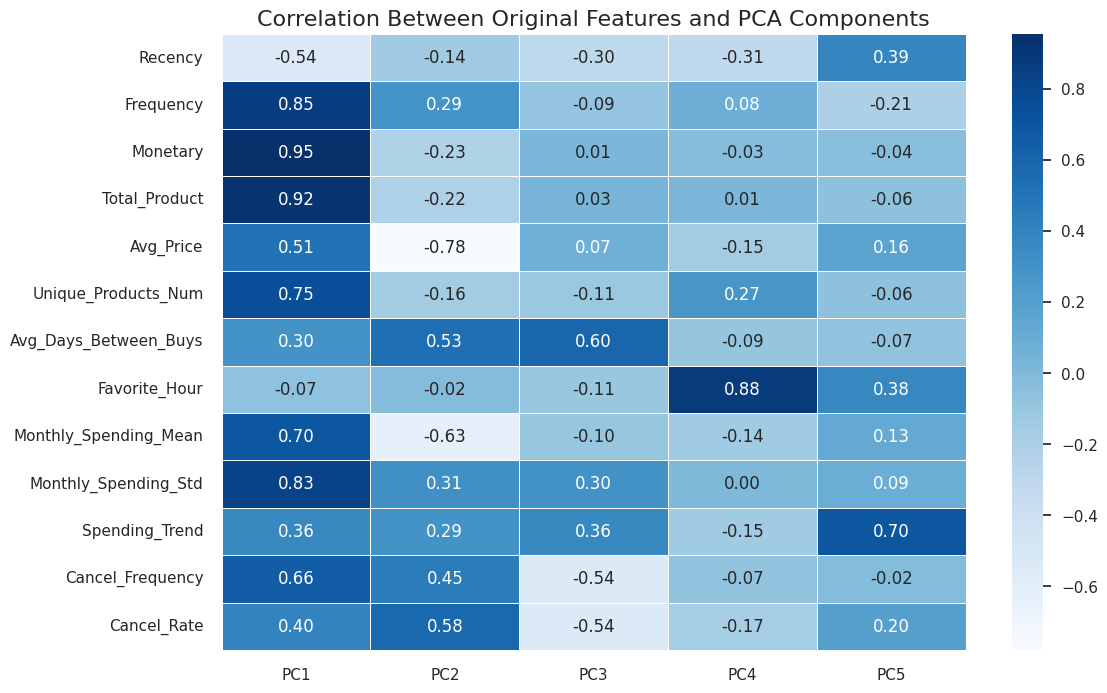

In [168]:
# Calculate the correlation between original features and the principal components
corr_matrix = pd.concat([customer_df_scaled.drop(columns=['UK', 'Favorite_Day']), pca_df], axis=1).corr()
heatmap_data = corr_matrix.loc[customer_df_scaled.drop(columns=['UK', 'Favorite_Day']).columns, pca_df.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)

plt.title('Correlation Between Original Features and PCA Components', fontsize=16)
plt.show()


<a id="setup"></a>
# <p style="background-color: #0e2f52; color:white; font-size:80%; font-family:Verdana; text-align:center; border-radius:15px;padding: 15px;"> Conclusion</p> 

Conclusion: Customer Behavior Analysis Through PCA

After conducting a thorough exploratory data analysis and applying Principal Component Analysis (PCA) to our online retail dataset, we have gained valuable insights about customer behaviour patterns through dimensionality reduction.

The PCA results provided an effective way to reduce our complex, multi-dimensional customer data into a more manageable form while preserving the essential information. With five principal components, we were able to capture approximately 81% of the total variance in the dataset, which represents a significant portion of the customer behaviour patterns.

- **PC1 (43% variance)** strongly correlates with monetary metrics (0.95), total products purchased (0.92), and frequency of purchases (0.85). This component primarily represents the overall spending behaviour and engagement level of customers.
- **PC2 (17% variance)** has a strong negative correlation with average price (-0.78) and monthly spending mean (-0.63), while positively correlating with cancellation rate (0.58) and average days between purchases (0.53). This pattern seems to represent price sensitivity and purchase consistency.
- **PC3 (10% variance)** shows a strong correlation with average days between purchases (0.60) and a negative correlation with cancellation frequency (-0.54). This component appears to capture purchasing rhythm and satisfaction.

- **PC4 (8% variance)** has a strong correlation with favourite hour (0.88), suggesting it represents timing preferences in shopping behaviour.
- **PC5 (7% variance)** correlates most strongly with spending trend (0.70) and recency (0.39), potentially indicating growth potential and recent activity patterns.

These five components provide a simplified yet comprehensive view of customer behaviour, enabling more effective customer profiling and targeting strategies. By transforming raw transaction data into these meaningful components, we can better understand the underlying patterns driving customer behaviour in this online retail environment.

As a next step, applying K-means clustering to these principal components would allow for effective customer segmentation, followed by the potential development of a recommendation system tailored to each segment's unique characteristics and preferences.

<div style="text-align: center; font-weight: bold;font-size:120%;">
 If you find this work helpful, don't forget to give it an 👍 UPVOTE! and join the discussion! 💬
</div>

<div style="color:white;
            display:fill;
            border-radius:10px;
            background-color:#0e2f52;
            font-size:140%;
            font-family:Verdana;
            letter-spacing:1px;
            padding: 20px;
            text-align:center;
            font-weight: bold;">
    Thank you...
</div>

---

<div style="text-align: center;">
  <b>Duygu Jones | Data Scientist </b>
    
  <br>
  Follow me:
  <a href="https://duygujones.vercel.app/">duygujones.com</a> | 
  <a href="https://www.linkedin.com/in/duygujones/">Linkedin</a> | 
  <a href="https://github.com/Duygu-Jones">GitHub</a> | 
  <a href="https://www.kaggle.com/duygujones">Kaggle</a> | 
  <a href="https://medium.com/@duygujones">Medium</a> | 
  <a href="https://public.tableau.com/app/profile/duygu.jones/vizzes">Tableau</a>

    
</div>    